# E77 · How languages carve up colour: the World Color Survey

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the **World Color Survey** (WCS; Kay, Berlin, Maffi, Merrifield & Cook 2009). Speakers of **110 unwritten languages** (about 25 each, 2,616 in all) named each of the **330 Munsell chips** of a standard palette, one at a time, and then marked the best example(s) - the **foci** - of each of their colour terms. 840,000 naming responses and 30,000 focus choices |
| **You will learn** | A **naming model**: the probability that a speaker uses term *t* for a chip as a softmax over terms whose logits are **quadratic functions of the chip's CIELAB colour** (a Gaussian-category model written in its well-conditioned natural form) · why a model on the **printed grid** has to know that hue is a circle · **speakers as a hierarchy**: pooling everyone as one person passes a per-chip check and fails a **per-speaker** one; speaker-level effects fix it and show which terms are shared and which are idiosyncratic · rare terms and an "other" category · **uncertainty displays when the data are colours**: glyphs, boundary lines whose width is a probability, disc charts of per-term probability surfaces with their intervals, a posterised "how a new speaker would see it" animation · two kinds of uncertainty kept apart: **what we do not know about the language** vs **how its speakers differ** · **comparing languages**: effective number of categories, shared boundaries, partition similarity · testing the classic claim that **category centres and foci cluster** across languages, with a hue-rotation null and a **Bayesian bootstrap over speakers** · **prediction and design**: naming by held-out speakers, and **which chip to show next** to learn a new speaker's categories fastest (adaptive expected information gain) |

## The setting

English speakers use eleven or so basic colour words. Many languages use fewer: some get by with three,
roughly "light", "dark or cool" and "warm or red"; others have six or eight terms but put the
boundaries elsewhere. Are the categories arbitrary conventions, or does every language carve the
same perceptual space along similar lines?

Berlin and Kay (1969) argued for strong universals from 20 languages. The **World Color Survey** was
set up to test that in the field: from the late 1970s, missionary linguists of SIL International
took a kit of 330 Munsell chips to speakers of 110 unwritten languages. Each speaker was shown the
chips one by one in a fixed random order and asked to name each; then, shown the whole palette, they
marked the best example of each of their terms (Kay & Cook 2015 give the history).

The data are unusually rich for a Bayesian: every speaker labels every chip, so we see both **the
language** (what its speakers share) and **the speakers** (how much they differ). And they pose a
display problem that runs through this colour series (E74, E76): the objects *are* colours, so colour
cannot also be used to show a probability.

| part | question | tool |
|---|---|---|
| A | What did speakers do? | the palette, raw naming maps, how many terms per language |
| B | How do we model naming? | softmax over quadratic CIELAB logits; prior predictive; grid vs CIELAB (the hue circle) |
| C | Do speakers agree? | pooled vs hierarchical; a per-speaker predictive check; rare terms |
| D | How do you show uncertainty on a colour chart? | glyph maps, boundary widths, disc charts, foci and safest exemplars, a new-speaker animation, a lineup |
| E | How do languages compare? | five languages from 3 to 9 terms: effective categories, shared boundaries, similarity |
| F | Do category centres cluster across languages? | all 110 languages, hue-rotation null, Bayesian bootstrap over speakers |
| G | Can we predict a new speaker, and what should we ask them? | held-out speakers, log score, calibration, adaptive chip choice |

In [1]:
import io
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from IPython.display import HTML, Image, display
from matplotlib import animation
from matplotlib.collections import LineCollection, PolyCollection

from pymc_challenges import data

RANDOM_SEED = 77
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)


def show_jpeg(fig, quality=85, dpi=90):
    """Figures full of coloured chips are far smaller as JPEG than PNG."""
    buf = io.BytesIO()
    fig.savefig(buf, format="jpeg", dpi=dpi, pil_kwargs={"quality": quality})
    plt.close(fig)
    display(Image(buf.getvalue()))

## A. What did speakers do?

Four files, built from the WCS archive by `tools/build_e77_wcs.py`. The archive
(linguistics.berkeley.edu/wcs, formerly www1.icsi.berkeley.edu/wcs) asks that published work based on
the data cite it, and states no other licence; the raw files were read from a GitHub mirror of the
archive (jvosten/wcs). Non-responses (`*`, `?`) are kept as `-1` and treated as missing at random -
2.8% of all responses, mostly from a few languages.

In [2]:
for name in ["wcs_naming", "wcs_terms", "wcs_chips", "wcs_languages"]:
    data.describe(name)
    print()
chips = data.load("wcs_chips")
terms = data.load("wcs_terms")
langs = data.load("wcs_languages").set_index("lang")
wcs = np.load(data.path("wcs_naming"))
NAMING, SPK_LANG, SPK_NR = wcs["naming"], wcs["lang"], wcs["speaker"]
print(f"{len(langs)} languages, {len(NAMING)} speakers, {NAMING.size:,} naming responses "
      f"({(NAMING < 0).mean():.1%} non-responses), {len(wcs['foci_chip']):,} focus choices")

wcs_naming: NumPy .npz (open data.path(...) with np.load): naming (2,616 speakers x 330 chips, int16 term code - see wcs_terms - or -1 for no response), lang, speaker, age (-1 unknown), sex ('M', 'F', ''); foci_lang, foci_speaker, foci_code, foci_chip (31k best-example choices; white/black bar choices mapped to chips A0/J0). 110 languages, ~24 speakers each; chip = column index + 1.
  source: World Color Survey (Kay, Berlin, Maffi, Merrifield & Cook 2009, The World Color Survey, CSLI Publications); WCS Data Archives, https://linguistics.berkeley.edu/wcs/data.html (formerly www1.icsi.berkeley.edu/wcs), which asks that published work cite the archives and states no other licence. Raw files read from the GitHub mirror jvosten/wcs (data-raw/). BUILT by tools/build_e77_wcs.py - keep the cached file.
  url:    https://raw.githubusercontent.com/jvosten/wcs/master/data-raw/term.txt

wcs_terms: One row per (language, term) used in the naming task: lang, code (0 = most used), abbrev (WCS abbrevi

### The palette

320 chromatic chips - 40 equally spaced Munsell hues (columns 1-40) at 8 lightness levels (rows B-I),
each at the highest chroma available - plus 10 achromatic chips from white (A0) to black (J0). The
archive gives each chip's CIELAB coordinates; we turn them into screen colours with the usual
CIELAB -> XYZ -> sRGB chain (D65 white, clipped to the sRGB gamut; many of these chips are more
saturated than a screen can show, so the swatches are approximations).

The grid is a flat picture of a **cylinder**: column 40 (a purplish red) sits next to column 1 (red).
In CIELAB, which is a (roughly) perceptual 3-D space, that closure is automatic.

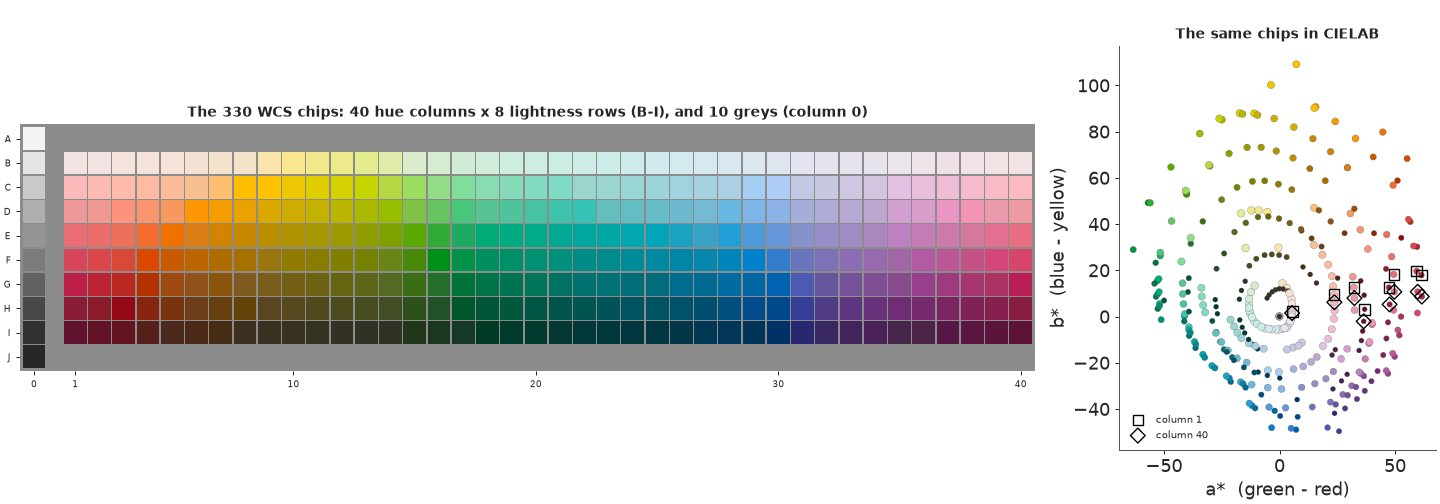

In [3]:
D65_WHITE_2DEG = np.array([0.95047, 1.0, 1.08883])
M_SRGB = np.array([[0.4124, 0.3576, 0.1805], [0.2126, 0.7152, 0.0722], [0.0193, 0.1192, 0.9505]])


def lab_to_srgb(lab):
    d = 6 / 29
    fy = (lab[..., 0] + 16) / 116
    f = np.stack([fy + lab[..., 1] / 500, fy, fy - lab[..., 2] / 200], -1)
    XYZ = np.where(f > d, f**3, 3 * d**2 * (f - 4 / 29)) * D65_WHITE_2DEG
    lin = np.clip(XYZ @ np.linalg.inv(M_SRGB).T, 0, 1)
    return np.where(lin <= 0.0031308, 12.92 * lin, 1.055 * lin ** (1 / 2.4) - 0.055)


ROWS = "ABCDEFGHIJ"
LAB = chips[["L", "a", "b"]].to_numpy()
RGB = lab_to_srgb(LAB)
ROW = chips.row.map(ROWS.index).to_numpy()
COL = chips.col.to_numpy()
XPOS = np.where(COL == 0, 0.0, COL + 0.7)          # achromatic column on the left, then a gap
YPOS = ROW.astype(float)
CHIP_AT = {(r, c): i for i, (r, c) in enumerate(zip(ROW, COL))}
DARK = LAB[:, 0] < 55                              # glyphs in white on dark chips


def edges():
    """Neighbouring chip pairs and the line segment(s) of their shared edge (the hue wrap gets two)."""
    E, segs = [], []
    for r in range(1, 9):
        for c in range(1, 41):
            i = CHIP_AT[(r, c)]
            j = CHIP_AT[(r, c % 40 + 1)]
            x = XPOS[i] + 0.5
            s = [[(x, r - 0.5), (x, r + 0.5)]]
            if c == 40:                             # 40 | 1: draw at both ends of the row
                s.append([(XPOS[j] - 0.5, r - 0.5), (XPOS[j] - 0.5, r + 0.5)])
            E.append((i, j))
            segs.append(s)
            if r < 8:
                E.append((i, CHIP_AT[(r + 1, c)]))
                segs.append([[(XPOS[i] - 0.5, r + 0.5), (XPOS[i] + 0.5, r + 0.5)]])
    for r in range(9):
        E.append((CHIP_AT[(r, 0)], CHIP_AT[(r + 1, 0)]))
        segs.append([[(-0.5, r + 0.5), (0.5, r + 0.5)]])
    return np.array(E), segs


EDGES, EDGE_SEGS = edges()
SQUARES = np.array([[(x - 0.47, y - 0.47), (x + 0.47, y - 0.47), (x + 0.47, y + 0.47), (x - 0.47, y + 0.47)]
                    for x, y in zip(XPOS, YPOS)])


def chip_grid(ax, face=RGB, edge_w=None, edge_color="k", labels=True, bg="0.55"):
    """The WCS palette: one square per chip in `face` colours; optional edge lines of width edge_w."""
    ax.add_collection(PolyCollection(SQUARES, facecolors=face, edgecolors="none"))
    if edge_w is not None:
        segs, lw = [], []
        for s, w in zip(EDGE_SEGS, edge_w):
            segs += s
            lw += [w] * len(s)
        keep = np.array(lw) > 0.05
        kept = [s for s, k in zip(segs, keep) if k]
        ax.add_collection(LineCollection(kept, linewidths=np.array(lw)[keep] + 1.6, colors="w", capstyle="round"))
        ax.add_collection(LineCollection(kept, linewidths=np.array(lw)[keep], colors=edge_color, capstyle="round"))
    ax.set_xlim(-0.6, 41.3)
    ax.set_ylim(9.6, -0.6)
    ax.set_aspect("equal")
    ax.set_facecolor(bg)
    if labels:
        ax.set_yticks(range(10), list(ROWS), fontsize=7)
        ax.set_xticks([0] + [c + 0.7 for c in (1, 10, 20, 30, 40)], ["0", "1", "10", "20", "30", "40"], fontsize=7)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


fig = plt.figure(figsize=(16, 5.6))
gs = fig.add_gridspec(1, 2, width_ratios=[3.2, 1])
ax = fig.add_subplot(gs[0])
chip_grid(ax)
ax.set_title("The 330 WCS chips: 40 hue columns x 8 lightness rows (B-I), and 10 greys (column 0)", fontsize=11)
ax = fig.add_subplot(gs[1])
ax.scatter(LAB[:, 1], LAB[:, 2], c=RGB, s=10 + 0.3 * LAB[:, 0], edgecolor="0.3", lw=0.2)
for c, m in ((1, "s"), (40, "D")):
    k = [CHIP_AT[(r, c)] for r in range(1, 9)]
    ax.scatter(LAB[k, 1], LAB[k, 2], s=70, marker=m, facecolor="none", edgecolor="k", lw=1.1, label=f"column {c}")
ax.legend(fontsize=8, loc="lower left")
ax.set_xlabel("a*  (green - red)")
ax.set_ylabel("b*  (blue - yellow)")
ax.set_aspect("equal")
ax.set_title("The same chips in CIELAB", fontsize=11)
show_jpeg(fig)

In the a*b* plane the hue columns form a closed ring, and columns 40 and 1 (the two lines) are
neighbours. The ring is lopsided: the most saturated yellows and reds reach much further from grey
than the blues and purples, and the yellows exist only at high lightness. Distances in CIELAB are
roughly perceptual, which is why we will model naming there.

### How many terms?

A "term" here is whatever a speaker said, as coded by the fieldworker. Many terms are used by one or
two speakers only (loanwords, descriptive phrases, object names). We call a term **major** if at
least a third of the language's speakers used it; everything else becomes one "other" category.

In [4]:
n_major = {}
for L, g in terms.groupby("lang"):
    n_major[L] = int((g.n_speakers >= langs.n_speakers[L] / 3).sum())
n_major = pd.Series(n_major)
n_all = terms.groupby("lang").size()
print(f"terms per language: all distinct terms median {int(n_all.median())}, range {n_all.min()}-{n_all.max()} | "
      f"major terms median {int(n_major.median())}, range {n_major.min()}-{n_major.max()}")
print("share of responses that fall in 'other' (median over languages):",
      f"{np.median([1 - terms[(terms.lang == L) & (terms.n_speakers >= langs.n_speakers[L] / 3)].n_responses.sum() / terms[terms.lang == L].n_responses.sum() for L in langs.index]):.1%}")
print("languages by number of major terms:", n_major.value_counts().sort_index().to_dict())

terms per language: all distinct terms median 16, range 3-79 | major terms median 8, range 3-20
share of responses that fall in 'other' (median over languages): 2.6%
languages by number of major terms: {3: 3, 4: 6, 5: 5, 6: 13, 7: 27, 8: 17, 9: 12, 10: 8, 11: 6, 12: 4, 13: 2, 14: 1, 15: 1, 16: 1, 17: 1, 19: 2, 20: 1}


Languages in the survey have between 3 and 20 major terms, most of them 6-9, while the number of
*distinct* things said runs to 79; the "other" bucket is small (a median of 2.6% of responses). The
rest of this notebook follows one language in detail and then compares it with others.

**Nafaanra** (a Gur language of Ghana; 29 speakers) is famous in this literature for a small system.
Its four major terms are coded W, N, F and B in the survey. Here is what its speakers did: each chip
is drawn in its own colour, with the letter of the term most speakers gave it; the letter's opacity is
the share of speakers who agreed with that majority.

Nafaanra: 29 speakers, terms ['W', 'N', 'F', 'B'], transcriptions: {'W': 'wɔɔ/wɔ', 'N': 'nye/nyie', 'F': 'finge', 'B': 'bubuo'}
responses per term: {'W': 5082, 'N': 2757, 'F': 1550, 'B': 173}


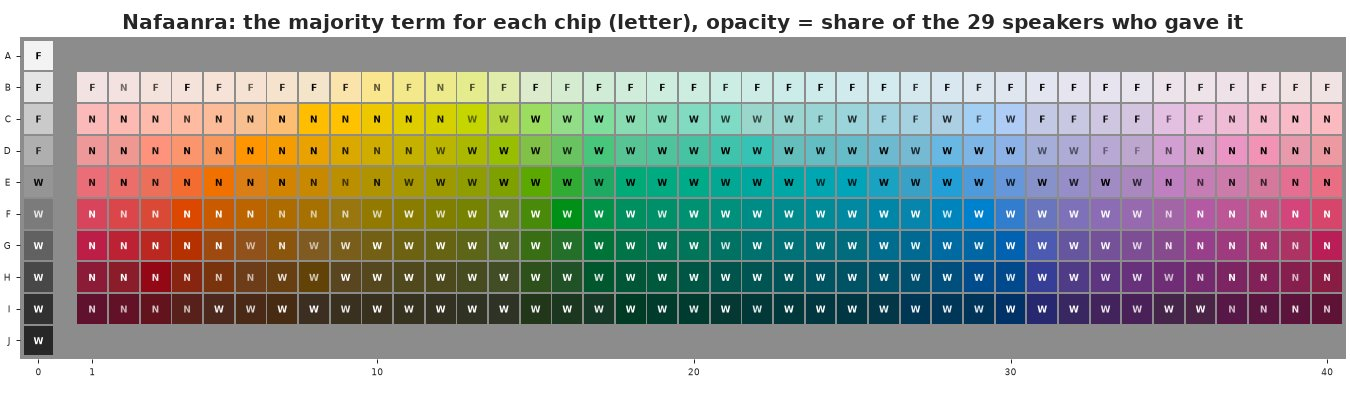

In [5]:
def lang_data(L, share=1 / 3):
    """Naming matrix (speakers x chips, -1 = missing) recoded to major terms + 'other', and the foci."""
    rows = np.flatnonzero(SPK_LANG == L)
    Y = NAMING[rows].astype(int)
    tl = terms[terms.lang == L].sort_values("code")
    major = (tl.n_speakers >= share * len(rows)).to_numpy()
    remap = np.full(tl.code.max() + 1, major.sum())
    remap[tl.code.to_numpy()[major]] = np.arange(major.sum())
    Yr = np.where(Y < 0, -1, remap[np.maximum(Y, 0)])
    names = tl.abbrev[major].tolist() + (["other"] if (~major).any() else [])
    fr = np.flatnonzero(wcs["foci_lang"] == L)
    spk_row = {s: i for i, s in enumerate(SPK_NR[rows])}
    ft = remap[wcs["foci_code"][fr]]
    ok = ft < major.sum()                                   # foci of major terms only
    foci = (np.array([spk_row.get(s, -1) for s in wcs["foci_speaker"][fr]])[ok], ft[ok], wcs["foci_chip"][fr][ok] - 1)
    gloss = dict(zip(tl.abbrev, tl.term))
    return dict(L=L, name=langs.name[L], Y=Yr, terms=names, T=len(names), S=len(rows), foci=foci,
                gloss={t: gloss.get(t, "") for t in names})


def counts(Y, T):
    """chip x term counts over speakers."""
    return np.stack([(Y == t).sum(0) for t in range(T)], 1)


NAF = lang_data(77)
cnt = counts(NAF["Y"], NAF["T"])
print(f"{NAF['name']}: {NAF['S']} speakers, terms {NAF['terms']}, transcriptions: {NAF['gloss']}")
print("responses per term:", dict(zip(NAF["terms"], cnt.sum(0).tolist())))


def glyphs(ax, term_idx, alpha, names, size=7.5, scale_size=False):
    for i in range(330):
        a = float(np.clip(alpha[i], 0, 1))
        ax.text(XPOS[i], YPOS[i] + 0.04, names[term_idx[i]], ha="center", va="center",
                fontsize=size * (0.55 + 0.45 * a) if scale_size else size, color="w" if DARK[i] else "k",
                alpha=0.15 + 0.85 * a, fontweight="bold")


fig, ax = plt.subplots(figsize=(15, 4.4))
chip_grid(ax)
share = cnt / cnt.sum(1, keepdims=True)
glyphs(ax, share.argmax(1), share.max(1), NAF["terms"])
ax.set_title(f"{NAF['name']}: the majority term for each chip (letter), opacity = share of the {NAF['S']} speakers who gave it")
show_jpeg(fig)

The raw data already show the shape of the system: **F** (*finge*) for white and the palest row;
**W** (*wɔɔ*) for the dark greys and black and for almost all greens, blues and purples of any
lightness; **N** (*nyie*) for the reds, oranges, pinks, browns and yellows. **B** is never the majority
term. Agreement is high in the cores and falls off at the edges, where the letters fade.

Those faded letters are the interesting part, and raw shares cannot tell us what they mean. Is a
55/45 split a fuzzy boundary that every speaker shares, or a crisp boundary that different speakers
put in different places? How sure are we of the boundary, given only 29 speakers? To answer we need a
model of how one speaker names one chip.

## B. A naming model

For a speaker naming chip $c$, with CIELAB colour $x_c$, the term is categorical with probabilities

$$P(y = t \mid x_c) = \operatorname{softmax}_t\big(\eta_t(x_c)\big), \qquad
\eta_t(x) = w_{t0} + w_t^\top x - \tfrac12\, x^\top Q_t\, x .$$

If $Q_t$ is positive definite this is a **Gaussian category**: $\eta_t$ is a log-Gaussian bump with
centre $Q_t^{-1} w_t$, and the softmax turns overlapping bumps into boundaries (it is the posterior of
a Gaussian classifier). The obvious parameterisation - centre, width and height per term - is badly
conditioned: a category whose centre sits far outside the palette with a huge width looks exactly
like a *linear* logit, so centre and width slide off to infinity together (a first prototype of this
notebook gave 56-94 divergences and r_hat up to 1.06 that way). Written as above, the model is a
**multinomial logistic regression on the 10 quadratic features** $1, L, a, b, L^2, a^2, b^2, ab, La, Lb$
(standardised): linear in its parameters and easy to sample. We do not force $Q_t$ to be positive
definite, so a term may be a bump, a ridge or a half-space ("everything dark").

A softmax does not change if the same number is added to every term's logit, so the weights of each
feature are **zero-sum over terms** (`pm.ZeroSumNormal`). The prior scale matters: logits span ±5-10
for crisp categories. A prior predictive check with a scale of 3:

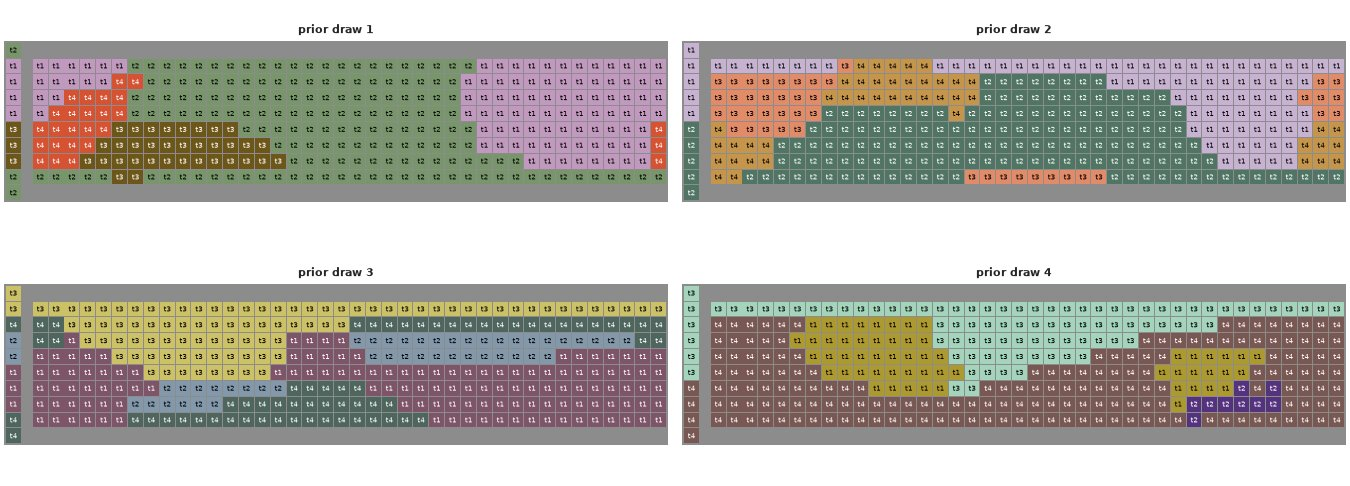

prior (4 terms): mean probability of the most likely term 0.91; terms that win at least one chip: [  0   0  10 190] (1, 2, 3, 4 terms, of 200 draws)


In [6]:
Lc, ac, bc = (LAB[:, 0] - 50) / 50, LAB[:, 1] / 50, LAB[:, 2] / 50


def standardise(F):
    return np.c_[np.ones(len(F)), (F - F.mean(0)) / F.std(0)]


FEATURES = {
    "CIELAB quadratic": standardise(np.c_[Lc, ac, bc, Lc**2, ac**2, bc**2, ac * bc, Lc * ac, Lc * bc]),
}
F_LAB = FEATURES["CIELAB quadratic"]
FEAT_NAMES = ["1", "L", "a", "b", "L2", "a2", "b2", "ab", "La", "Lb"]


def softmax(eta):
    e = np.exp(eta - eta.max(-1, keepdims=True))
    return e / e.sum(-1, keepdims=True)


def exemplar_colours(P):
    """A display colour per term: the CIELAB mean of the chips, weighted by P(term | chip)^8 (its core)."""
    w = P**8 + 1e-300
    return lab_to_srgb((w.T @ LAB) / w.sum(0)[:, None])


def posterised(ax, P, names=None, edge=None, title=None, glyph=True, labels=False):
    """Each chip painted in the exemplar colour of its most probable term."""
    face = exemplar_colours(P)[P.argmax(1)]
    chip_grid(ax, face=face, edge_w=edge, labels=labels)
    if glyph and names is not None:
        for i in range(330):
            ax.text(XPOS[i], YPOS[i] + 0.04, names[P[i].argmax()], ha="center", va="center", fontsize=5.5,
                    color="w" if lab_to_srgb_L(face[i]) < 0.5 else "k")
    if title:
        ax.set_title(title, fontsize=9)


def lab_to_srgb_L(rgb):
    return 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]


rng_p = np.random.default_rng(RANDOM_SEED + 1)
fig, axs = plt.subplots(2, 2, figsize=(15, 5.4))
prior_stats = []
for k in range(200):
    W = rng_p.normal(0, 3, (10, 4))
    W -= W.mean(1, keepdims=True)
    P = softmax(F_LAB @ W)
    prior_stats.append((P.max(1).mean(), len(np.unique(P.argmax(1)))))
    if k < 4:
        posterised(axs.flat[k], P, names=["t1", "t2", "t3", "t4"], title=f"prior draw {k + 1}")
show_jpeg(fig)
ps = np.array(prior_stats)
print(f"prior (4 terms): mean probability of the most likely term {ps[:, 0].mean():.2f}; "
      f"terms that win at least one chip: {np.bincount(ps[:, 1].astype(int), minlength=5)[1:]} (1, 2, 3, 4 terms, of 200 draws)")

Each prior draw is a possible four-term language, painted in "poster" style: every chip takes the
display colour of its most probable term (the average colour of the term's core chips, where its
probability is highest), so a draw shows its partition directly. The prior
makes contiguous regions in colour space with fairly crisp edges (the most probable term has on
average about 0.9 of the probability), and now and then (10 of 200 draws) a term that wins no chip
at all. It does not know that lightness matters more than hue, or that languages have
a "dark" term: the data must say that.

### Does the model need to know that hue is a circle?

A tempting shortcut is to model naming on the printed grid: row and hue column as two numbers. That
treats hue as a line from column 1 to column 40, although columns 40 and 1 are neighbours. We compare
three feature sets, each a quadratic surface of the same kind, fitted to all speakers pooled as if
they were one (the next section says why that is not enough):

* **grid, hue as a line**: row, column, their squares and product, and an indicator for the greys;
* **grid, hue as a circle**: row, $\cos\theta, \sin\theta, \cos 2\theta, \sin 2\theta$ with
  $\theta = 2\pi\,\text{column}/40$, row x (cos, sin), row², and the grey indicator;
* **CIELAB quadratic**, as above.

To compare them fairly we **hold out speakers**: fit on 20 randomly chosen Nafaanra speakers and score
the naming of the other 9 by the log posterior-predictive probability per response. Pooling makes the
per-chip probabilities a multinomial regression on the chip x term count table, so these fits take
seconds.

In [7]:
theta = 2 * np.pi * COL / 40
chrom = (COL > 0).astype(float)
FEATURES["grid, hue as a line"] = standardise(np.c_[ROW, COL, ROW**2, COL**2, ROW * COL, 1 - chrom])
FEATURES["grid, hue as a circle"] = standardise(np.c_[ROW, chrom * np.cos(theta), chrom * np.sin(theta),
                                                      chrom * np.cos(2 * theta), chrom * np.sin(2 * theta),
                                                      ROW * chrom * np.cos(theta), ROW * chrom * np.sin(theta),
                                                      ROW**2, 1 - chrom])


def naming_model(Y, names, F=F_LAB, hier=True, n_rand=4, mask=None, w_sd=3.0):
    """Softmax naming model. hier=False pools all speakers; hier=True gives every speaker their own
    intercept and linear (L, a, b) weights, drawn around the language's."""
    S, C = Y.shape
    T, K = len(names), F.shape[1]
    ok = (Y >= 0) if mask is None else (Y >= 0) & mask
    onehot = np.zeros((S, C, T))
    s_i, c_i = np.nonzero(ok)
    onehot[s_i, c_i, Y[s_i, c_i]] = 1
    feat = (FEAT_NAMES if K == 10 else [f"f{k}" for k in range(K)])
    coords = {"term": names, "speaker": np.arange(S), "feat": feat, "rfeat": feat[:n_rand]}
    with pm.Model(coords=coords) as m:
        W = pm.ZeroSumNormal("W", w_sd, dims=("feat", "term"))
        if hier:
            sd = pm.HalfNormal("sd", 1.0, dims=("rfeat", "term"))
            z = pm.ZeroSumNormal("z", 1.0, dims=("speaker", "rfeat", "term"))
            Ws = W[None] + pt.concatenate([sd[None] * z, pt.zeros((S, K - n_rand, T))], axis=1)
            eta = pt.einsum("ck,skt->sct", pt.as_tensor(F), Ws)
            pm.Potential("loglik", ((eta - pt.logsumexp(eta, axis=-1, keepdims=True)) * onehot).sum())
        else:
            eta = pt.dot(F, W)
            pm.Potential("loglik", ((eta - pt.logsumexp(eta, axis=-1, keepdims=True)) * onehot.sum(0)).sum())
    return m


def fit(model, label, draws=1000):
    t0 = time.time()
    idata = pm.sample(draws=draws, model=model, random_seed=RANDOM_SEED, progressbar=False)
    st = idata.sample_stats
    msg = (f"{label:34s} {time.time() - t0:4.0f} s | divergences {int(st['diverging'].sum())}, mean tree depth "
           f"{float(st['depth'].mean()):.1f}, max r_hat(W) {float(az.rhat(idata.posterior['W']).max()):.3f}, "
           f"min ESS(W) {float(az.ess(idata.posterior['W']).min()):.0f}")
    if "sd" in idata.posterior:
        msg += (f", max r_hat(sd) {float(az.rhat(idata.posterior['sd']).max()):.3f}, "
                f"min ESS(sd) {float(az.ess(idata.posterior['sd']).min()):.0f}")
    print(msg)
    return idata


def draws_of(idata, name, n=400):
    """(n, ...) evenly thinned posterior draws of one variable, sample axis first."""
    x = idata.posterior[name].stack(s=("chain", "draw")).transpose("s", ...).values
    return x[np.linspace(0, len(x) - 1, n).astype(int)]


rng_split = np.random.default_rng(RANDOM_SEED + 2)
perm_spk = rng_split.permutation(NAF["S"])
TRAIN, TEST = np.sort(perm_spk[:20]), np.sort(perm_spk[20:])
Ytr, Yte = NAF["Y"][TRAIN], NAF["Y"][TEST]


def heldout_score(P_draws, Y):
    """Mean log posterior-predictive probability per response (P_draws: draws x chips x terms),
    overall and per held-out speaker."""
    Pm = P_draws.mean(0)
    s, c = np.nonzero(Y >= 0)
    lp = np.log(Pm[c, Y[s, c]])
    return lp.mean(), np.array([lp[s == k].mean() for k in range(len(Y))]), lp


pooled_P, grid_rows = {}, []
for fname, F in FEATURES.items():
    idata = fit(naming_model(Ytr, NAF["terms"], F=F, hier=False), f"pooled, {fname}")
    Wd = draws_of(idata, "W")
    pooled_P[fname] = softmax(np.einsum("ck,dkt->dct", F, Wd))
    grid_rows.append((fname, heldout_score(pooled_P[fname], Yte)))
base, base_all = grid_rows[0][1][1], grid_rows[0][1][2]
print("\nlog score per response on the 9 held-out speakers (higher is better); difference to CIELAB, "
      "mean ± se over the 9 speakers:")
for fname, (sc, per_spk, lp) in grid_rows:
    dlt = per_spk - base
    print(f"  {fname:24s} {sc:.3f}   diff {dlt.mean():+.3f} ± {dlt.std(ddof=1) / np.sqrt(len(dlt)):.3f}  "
          f"(summed over {len(lp)} responses: {(lp - base_all).sum():+.0f} nats)")

pooled, CIELAB quadratic              3 s | divergences 0, mean tree depth 4.4, max r_hat(W) 1.003, min ESS(W) 1466


pooled, grid, hue as a line           2 s | divergences 0, mean tree depth 5.4, max r_hat(W) 1.003, min ESS(W) 1310


pooled, grid, hue as a circle         2 s | divergences 0, mean tree depth 5.0, max r_hat(W) 1.003, min ESS(W) 811

log score per response on the 9 held-out speakers (higher is better); difference to CIELAB, mean ± se over the 9 speakers:
  CIELAB quadratic         -0.392   diff +0.000 ± 0.000  (summed over 2970 responses: +0 nats)
  grid, hue as a line      -0.426   diff -0.034 ± 0.008  (summed over 2970 responses: -101 nats)
  grid, hue as a circle    -0.396   diff -0.004 ± 0.005  (summed over 2970 responses: -13 nats)


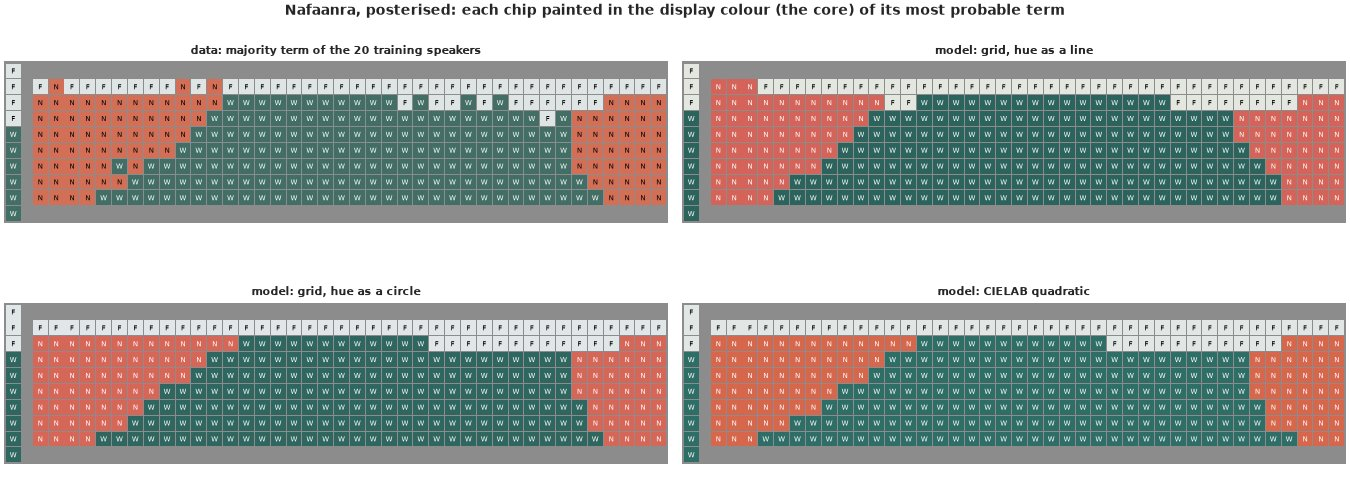

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(15, 5.6))
emp = counts(Ytr, NAF["T"]) + 1e-9
posterised(axs[0, 0], emp / emp.sum(1, keepdims=True), NAF["terms"], title="data: majority term of the 20 training speakers")
for ax, fname in zip(axs.flat[1:], ["grid, hue as a line", "grid, hue as a circle", "CIELAB quadratic"]):
    posterised(ax, pooled_P[fname].mean(0), NAF["terms"], title=f"model: {fname}")
fig.suptitle("Nafaanra, posterised: each chip painted in the display colour (the core) of its most probable term", fontsize=11)
show_jpeg(fig)

All three fits are clean. On the held-out speakers, the grid model with **hue as a line** is worse than
CIELAB by 0.034 ± 0.008 nats per response (se over speakers), about 100 nats over the 2,970 held-out
responses. Making **hue a circle** recovers almost all of it (-0.004 ± 0.005, within noise of CIELAB).
The line model is not hopeless: its column² term bends into a U, so the red category (N) can still
appear at both ends of the grid. But the U is the wrong shape - it also paints the palest reds of
row B (B1-B3) as N, where speakers said F. The circle model and CIELAB draw almost the same map. We keep CIELAB: it gets the hue
circle and the greys right without special features, and distances in it are roughly perceptual, so a
quadratic in it is a sensible shape for a category.

## C. Do speakers agree? Pooled vs hierarchical

The pooled model says every speaker names chip $c$ with the same probabilities. That is a strong claim:
it says that when 55% of speakers call a chip N and 45% call it W, *each* speaker tosses a 55/45 coin -
rather than, say, some speakers having a bigger N category than others. The per-chip shares cannot
tell these apart, but **each speaker's whole naming** can: if speakers differ, a speaker who calls one
boundary chip N will call its neighbours N too, and the number of chips each speaker gives each term
will vary more between speakers than coin tosses allow.

The **hierarchical** model gives each speaker $s$ their own intercept and linear weights (on L, a, b)
for every term, drawn around the language's:

$$w^{(s)}_{tk} = w_{tk} + \sigma_{tk}\, z_{stk}, \qquad z_{s\cdot k} \sim \text{ZeroSumNormal}(1), \quad
\sigma_{tk} \sim \text{HalfNormal}(1), \quad k \in \{1, L, a, b\},$$

non-centred. A speaker can thus use a term more or less (intercept) and shift its boundaries along
lightness and in the a*b* plane (linear weights), while the quadratic shape is the language's. This
also answers the question of **overdispersion**: each speaker names each chip once, so there is no
within-speaker overdispersion to model; all the extra variation in the per-chip counts across speakers
comes from differences between speakers, and this is where it goes. Rare terms need no special
treatment beyond the "other" bucket: a term that only some speakers use gets a large $\sigma$ on its
intercept.

We fit both to all 29 Nafaanra speakers.

In [9]:
idata_pool = fit(naming_model(NAF["Y"], NAF["terms"], hier=False), "Nafaanra, pooled")
idata_hier = fit(naming_model(NAF["Y"], NAF["terms"]), "Nafaanra, hierarchical")
print(f"tuning steps (nutpie default): {idata_hier.posterior.attrs.get('tuning_steps')}")
print("\nbetween-speaker sd of each term's weights (posterior mean):")
print(idata_hier.posterior["sd"].mean(("chain", "draw")).to_pandas().round(2))

Nafaanra, pooled                      2 s | divergences 0, mean tree depth 4.5, max r_hat(W) 1.004, min ESS(W) 1447


Nafaanra, hierarchical               18 s | divergences 0, mean tree depth 5.0, max r_hat(W) 1.012, min ESS(W) 344, max r_hat(sd) 1.005, min ESS(sd) 728
tuning steps (nutpie default): 400

between-speaker sd of each term's weights (posterior mean):
term      W     N     F     B
rfeat                        
1      0.25  0.36  0.47  2.61
L      0.56  0.09  0.22  0.44
a      0.54  0.55  0.13  1.13
b      0.35  0.29  0.10  0.19


Both samplers are clean (no divergences, r_hat at most about 1.01). The between-speaker standard deviations
already tell a story, on the logit scale of standardised features: the three main terms have small
intercept sds (0.25-0.47: speakers use them at similar rates), while **B has an intercept sd of about
2.6** - some speakers use it for a patch of chips and others never do. The larger linear sds (W on
lightness and a*, N on a*) say that speakers put the light/dark and warm/cool boundaries in
somewhat different places.

### A per-speaker predictive check

Simulate new sets of 29 speakers from each model (with the same missing responses) and compare, term
by term, how many chips each speaker gives the term. For the pooled model a "new speaker" is the
population itself; for the hierarchical model it has fresh speaker effects drawn from the fitted
population.

B: 16 of 29 speakers never use it; the others use it for 1-24 chips
standard deviation across speakers of the number of chips given each term:
      observed sd pooled: 90% interval  pooled: P(rep >= obs) hierarchical: 90% interval  hierarchical: P(rep >= obs)
term                                                                                                                 
W            8.92            4.0 - 6.4                    0.0                 8.6 - 17.8                         0.93
N           10.44            4.0 - 6.0                    0.0                10.2 - 19.9                         0.93
F            9.53            3.1 - 5.0                    0.0                 8.0 - 15.6                         0.78
B            8.08            1.8 - 2.9                    0.0                 3.4 - 31.8                         0.74


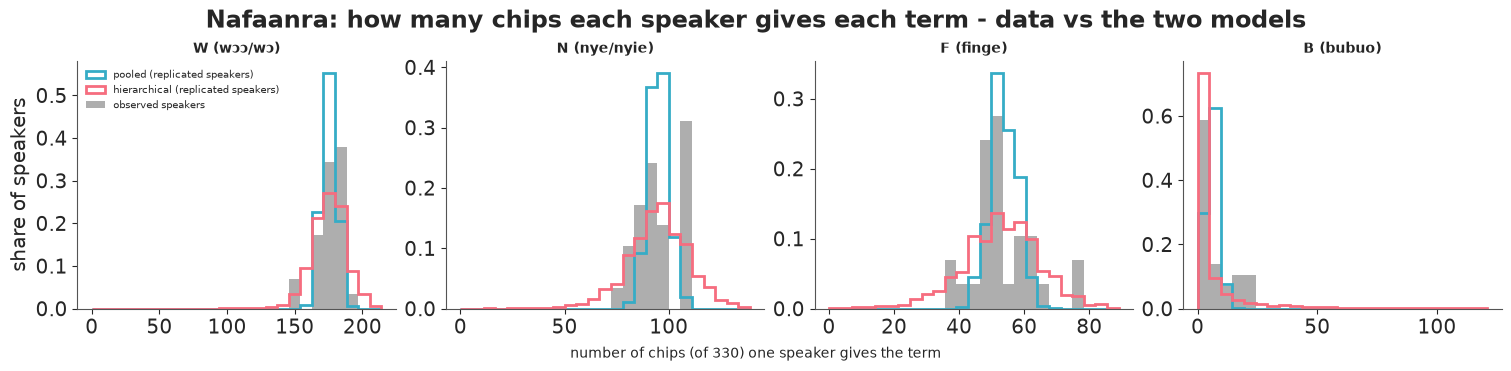

In [10]:
def entropy(p, axis=-1):
    return -(p * np.log(np.clip(p, 1e-300, 1))).sum(axis)


def new_speaker_probs(idata, F=F_LAB, n_draws=400, n_new=20, seed=0, n_rand=4):
    """For each of n_draws posterior draws: choice probabilities (n_new x chips x terms) of new speakers."""
    Wd, sdd = draws_of(idata, "W", n_draws), draws_of(idata, "sd", n_draws)
    g = np.random.default_rng(seed)
    T = Wd.shape[-1]
    for d in range(n_draws):
        z = g.standard_normal((n_new, n_rand, T))
        z -= z.mean(-1, keepdims=True)                       # zero-sum over terms, as in the model
        Ws = np.repeat(Wd[d][None], n_new, 0)
        Ws[:, :n_rand] += sdd[d][None] * z
        yield softmax(np.einsum("ck,nkt->nct", F, Ws))


def sample_names(P, g):
    """One categorical draw per row of P (..., terms)."""
    u = g.random(P.shape[:-1])[..., None]
    return np.minimum((P.cumsum(-1) < u).sum(-1), P.shape[-1] - 1)


def per_speaker_counts(Y, T):
    return np.stack([(Y == t).sum(1) for t in range(T)], 1)


T_N, S_N = NAF["T"], NAF["S"]
MASK = NAF["Y"] >= 0
obs_cnt = per_speaker_counts(NAF["Y"], T_N)
g = np.random.default_rng(RANDOM_SEED + 3)
P_pool = softmax(np.einsum("ck,dkt->dct", F_LAB, draws_of(idata_pool, "W", 200)))
rep = {"pooled": [], "hierarchical": []}
for d, p_new in enumerate(new_speaker_probs(idata_hier, n_draws=200, n_new=S_N, seed=RANDOM_SEED + 4)):
    for name, P in (("pooled", np.broadcast_to(P_pool[d], (S_N, 330, T_N))), ("hierarchical", p_new)):
        y = np.where(MASK, sample_names(P, g), -1)
        rep[name].append(per_speaker_counts(y, T_N))
rep = {k: np.array(v) for k, v in rep.items()}                          # draws x speakers x terms
rows_ = []
for t, tn in enumerate(NAF["terms"]):
    o = obs_cnt[:, t].std()
    row = {"term": tn, "observed sd": o}
    for k, r in rep.items():
        sds = r[:, :, t].std(1)
        row[f"{k}: 90% interval"] = f"{np.quantile(sds, 0.05):.1f} - {np.quantile(sds, 0.95):.1f}"
        row[f"{k}: P(rep >= obs)"] = (sds >= o).mean()
    rows_.append(row)
print(f"B: {(obs_cnt[:, -1] == 0).sum()} of {S_N} speakers never use it; the others use it for "
      f"{obs_cnt[obs_cnt[:, -1] > 0, -1].min()}-{obs_cnt[:, -1].max()} chips")
print("standard deviation across speakers of the number of chips given each term:")
print(pd.DataFrame(rows_).set_index("term").round(2))

fig, axs = plt.subplots(1, T_N, figsize=(15, 3.6))
for t, ax in enumerate(axs):
    hi = max(obs_cnt[:, t].max(), np.quantile(rep["hierarchical"][:, :, t], 0.995)) + 5
    bins = np.linspace(0, hi, 26)
    for k, col in (("pooled", "C0"), ("hierarchical", "C1")):
        ax.hist(rep[k][:, :, t].ravel(), bins=bins, weights=np.full(rep[k][:, :, t].size, 1 / rep[k][:, :, t].size),
                histtype="step", lw=2, color=col, label=f"{k} (replicated speakers)")
    ax.hist(obs_cnt[:, t], bins=bins, weights=np.full(S_N, 1 / S_N), color="0.3", alpha=0.45, label="observed speakers")
    ax.set_title(f"{NAF['terms'][t]} ({NAF['gloss'][NAF['terms'][t]]})", fontsize=10)
axs[0].set_ylabel("share of speakers")
fig.supxlabel("number of chips (of 330) one speaker gives the term", fontsize=10)
axs[0].legend(fontsize=7)
fig.suptitle("Nafaanra: how many chips each speaker gives each term - data vs the two models");

**The pooled model fails the per-speaker check for every term.** Its replicated speakers are far too
alike: the standard deviation across speakers of the number of chips called W is 4.0-6.4 in its
replications against 8.9 in the data, and not one of 200 replicated sets of speakers is as varied as
the real one, for any term. The histograms show it directly (the pooled model's replicated speakers are
the narrow blue curves). **The hierarchical model reproduces the spread** (the observed sds sit inside
its replications, P(rep >= obs) 0.74-0.93, so it allows if anything a little more variation than
observed).

**B** is the clearest case. The pooled model says every speaker uses B for a handful of chips; in the
data 16 of the 29 speakers never use it, and those who do use it for 1-24 chips. The
hierarchical model gets there with its large intercept sd, but its replications also include speakers
who use B for 50 or more chips, which no real speaker does: a speaker-level shift of a shared shape is
a crude description of a term that some speakers have and others do not (a "knows B or not" mixture
would be the next model).

Note what the pooled model got right: the *per-chip* shares, which is all the maps of Part B look at.
A model can match every margin of the data and still misdescribe how the data were generated; only a
check at the level of the real unit - here the speaker - shows it.

## D. Showing uncertainty on a colour chart

The chips are colours, so a chip's colour cannot show a probability. Everything below keeps each chip
in its own colour and puts the uncertainty in other channels: **letters** (which term), their **size
and opacity** (how probable), **lines between chips** whose width is a probability, **discs** whose
area is a probability, and **time** (an animation).

There are two different uncertainties here and it pays to keep them apart:

* **variation between speakers** - even if we knew the language perfectly, a new speaker names a
  boundary chip one way or the other; this is the posterior predictive for a *new speaker*;
* **what we do not know about the language** - with 29 speakers, where exactly is the chip at which
  half the speakers would switch from N to W? This is the posterior of the language-level quantities.

We compute both from 400 posterior draws, each with 20 simulated new speakers.

In [11]:
i_e, j_e = EDGES.T


def summarise(idata, n_draws=400, n_new=20, seed=0):
    """Language-level and new-speaker summaries from the hierarchical posterior.
    P: draws x chips x terms, the share of the language's speakers who would give each term (population);
    edge: P(a new speaker names the two chips of an edge differently); keff: effective number of categories
    of a typical speaker, exp(mutual information between chip and term), per draw."""
    Pbar, edge, keff = [], np.zeros(len(EDGES)), []
    for p in new_speaker_probs(idata, n_draws=n_draws, n_new=n_new, seed=seed):
        Pbar.append(p.mean(0))
        edge += 1 - (p[:, i_e] * p[:, j_e]).sum(-1).mean(0)
        keff.append(np.exp(entropy(p.mean(1)) - entropy(p).mean(1)).mean())
    return dict(P=np.array(Pbar), edge=edge / n_draws, keff=np.array(keff))


SUM = {77: summarise(idata_hier, seed=RANDOM_SEED + 5)}
PN = SUM[77]["P"]
P_mean = PN.mean(0)
modal_draws = PN.argmax(2)
edge_lang = (modal_draws[:, i_e] != modal_draws[:, j_e]).mean(0)       # P(the language's majority boundary is here)
print(f"edges where the majority boundary is certain (posterior probability > 0.95): {(edge_lang > 0.95).sum()}, "
      f"uncertain (0.05-0.95): {((edge_lang > 0.05) & (edge_lang <= 0.95)).sum()} of {len(EDGES)}")
print(f"chips whose majority term is uncertain (P < 0.95 across draws): "
      f"{((modal_draws == P_mean.argmax(1)).mean(0) < 0.95).sum()} of 330")
print(f"new-speaker probability of the majority term: median {np.median(P_mean.max(1)):.2f}, "
      f"below 0.7 for {(P_mean.max(1) < 0.7).sum()} chips")

edges where the majority boundary is certain (posterior probability > 0.95): 38, uncertain (0.05-0.95): 77 of 609
chips whose majority term is uncertain (P < 0.95 across draws): 26 of 330
new-speaker probability of the majority term: median 0.88, below 0.7 for 71 chips


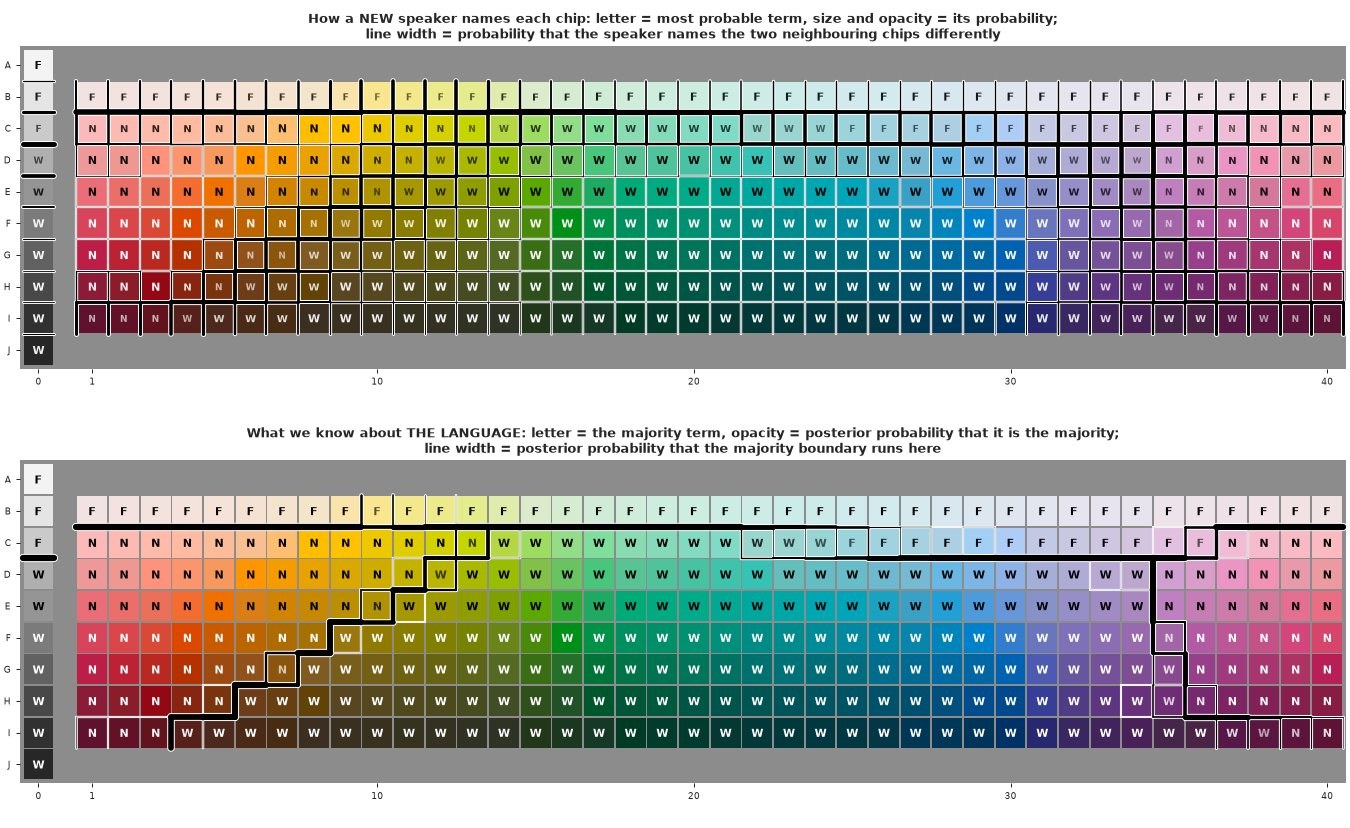

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(15, 9.2))
chip_grid(axs[0], edge_w=6 * SUM[77]["edge"])
glyphs(axs[0], P_mean.argmax(1), P_mean.max(1), NAF["terms"], size=9, scale_size=True)
axs[0].set_title("How a NEW speaker names each chip: letter = most probable term, size and opacity = its probability;\n"
                 "line width = probability that the speaker names the two neighbouring chips differently", fontsize=10)
chip_grid(axs[1], edge_w=5 * edge_lang)
cert = (modal_draws == P_mean.argmax(1)).mean(0)
glyphs(axs[1], P_mean.argmax(1), cert, NAF["terms"], size=9)
axs[1].set_title("What we know about THE LANGUAGE: letter = the majority term, opacity = posterior probability that it is the majority;\n"
                 "line width = posterior probability that the majority boundary runs here", fontsize=10)
show_jpeg(fig)

The two panels answer different questions.

**Top, speakers.** For a new speaker, the most probable term has probability 0.88 or more on half the
chips, and below 0.7 on 71 chips, which lie along the boundaries. The boundary lines are **bands**,
not lines: where the F/rest boundary under row B is almost certain for every speaker, the N/W boundary
(the diagonal running from the dark browns up to the yellow-greens, and the purple/red boundary around
columns 34-37) is spread over several chips, each crossed by a new speaker with some probability.

**Bottom, the language.** With 29 speakers, the place where the *majority* switches from one term to
the next is known to within about one chip: 38 edges carry the majority boundary with posterior
probability above 0.95, 77 edges have some doubt, and only 26 chips have a majority term we are not
sure of (opacity below 0.95). Uncertainty about the language is much smaller than the variation between
its speakers.

### Per-term probability surfaces, with their uncertainty

One small map per term. Each chip becomes a **disc chart**: a disc in the chip's own colour whose area
is the *lower* end of the 90% posterior interval of the share of speakers who would use the term for
it, and a thin ring whose area is the *upper* end. A full, ringless disc means "certainly most
speakers"; a small disc inside a large ring means "we do not know". Black dots are the speakers' foci
(best examples) for the term, dot area = number of speakers who chose that chip. The white star is
the **safest exemplar**: the chip with the highest predicted probability that a new speaker gives it
this term.

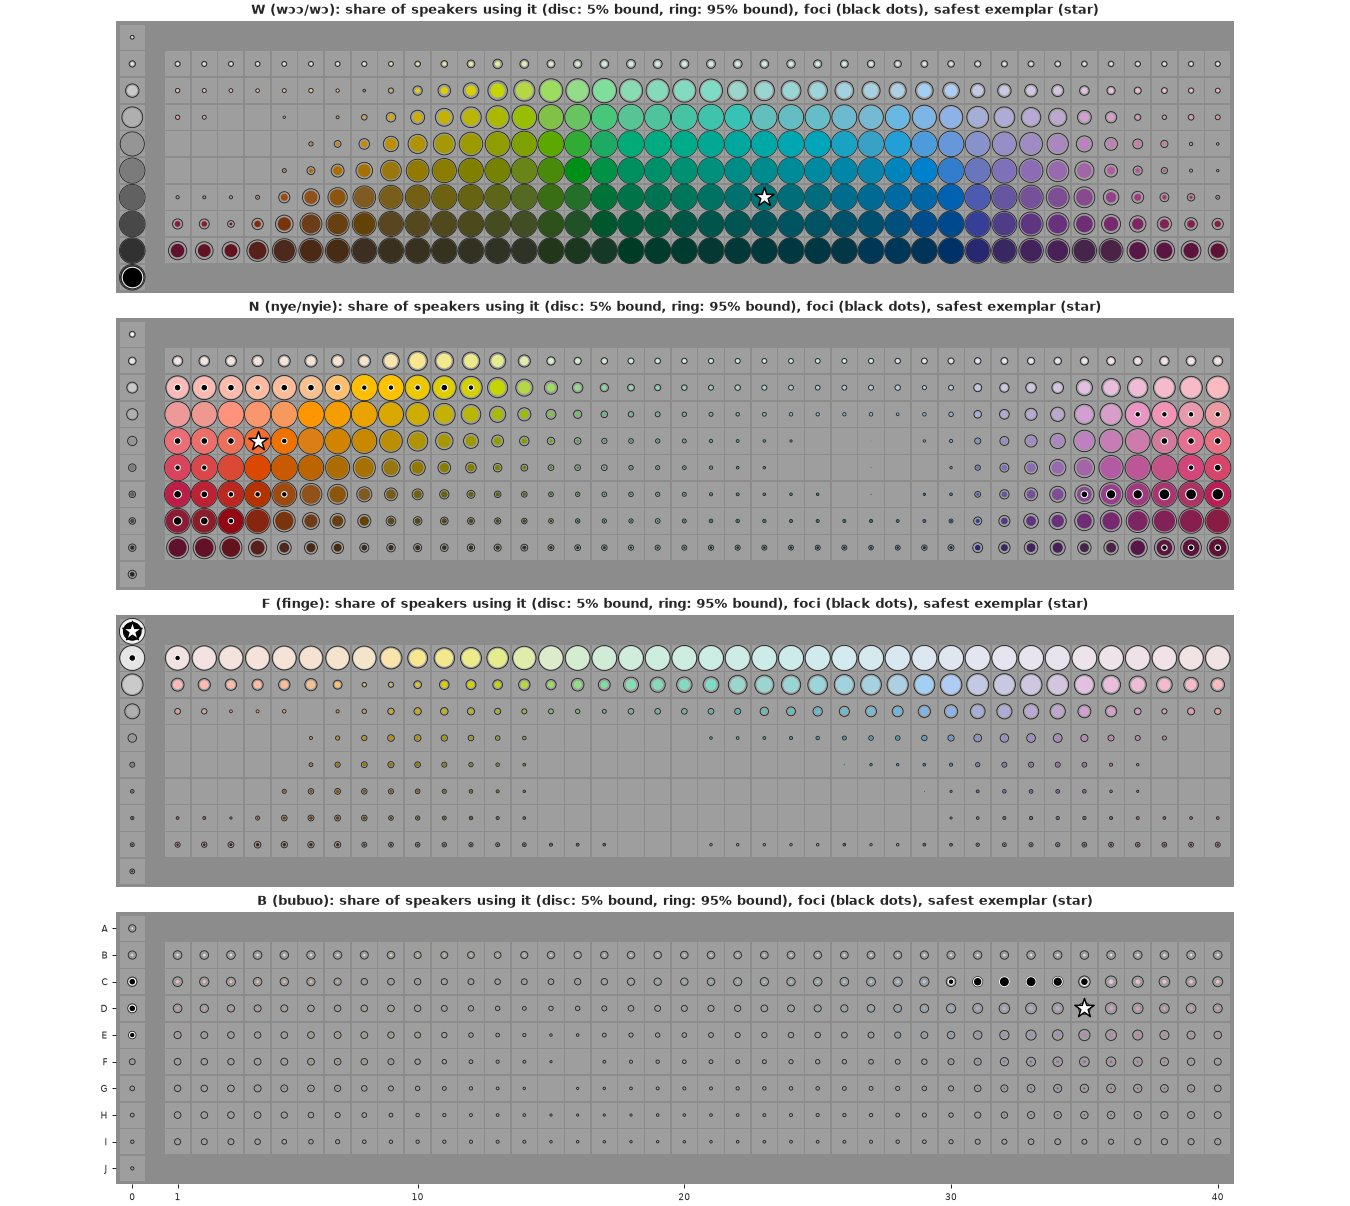

     safest exemplar P(new speaker uses it) foci (speakers) most chosen focus  speakers choosing it P at that focus CIELAB distance exemplar - foci mean
term                                                                                                                                                    
W                G23      0.99 [0.97, 1.00]         29 (29)                J0                    29            0.92                                   46
N                 E4      0.98 [0.94, 1.00]         96 (29)               G40                     8            0.97                                   43
F                 A0      0.93 [0.88, 0.96]         30 (29)                A0                    27            0.93                                    1
B                D35      0.11 [0.04, 0.21]         30 (11)               C32                     6            0.08                                   23


In [13]:
lo, hi = np.quantile(PN, [0.05, 0.95], axis=0)
f_spk, f_term, f_chip = NAF["foci"]
fig, axs = plt.subplots(T_N, 1, figsize=(15, 3.35 * T_N))
safest = P_mean.argmax(0)
for t, ax in enumerate(axs):
    chip_grid(ax, face=np.full((330, 3), 0.62), labels=t == T_N - 1)
    r_hi, r_lo = 0.49 * np.sqrt(hi[:, t]), 0.49 * np.sqrt(lo[:, t])
    for i in range(330):
        if r_hi[i] > 0.04:
            ax.add_patch(plt.Circle((XPOS[i], YPOS[i]), r_hi[i], fill=False, lw=0.7, color="0.15"))
        if r_lo[i] > 0.02:
            ax.add_patch(plt.Circle((XPOS[i], YPOS[i]), r_lo[i], color=RGB[i], lw=0))
    fc = np.bincount(f_chip[f_term == t], minlength=330)
    k = fc > 0
    ax.scatter(XPOS[k], YPOS[k], s=10 + 9 * fc[k], color="k", edgecolor="w", lw=0.8, zorder=5)
    ax.scatter(XPOS[safest[t]], YPOS[safest[t]], marker="*", s=260, color="w", edgecolor="k", lw=1.2, zorder=6)
    ax.set_title(f"{NAF['terms'][t]} ({NAF['gloss'][NAF['terms'][t]]}): share of speakers using it (disc: 5% bound, "
                 f"ring: 95% bound), foci (black dots), safest exemplar (star)", fontsize=10)
show_jpeg(fig)

rows_ = []
for t, tn in enumerate(NAF["terms"]):
    fc = f_chip[f_term == t]
    c0 = safest[t]
    top = np.bincount(fc, minlength=330).argmax() if len(fc) else -1
    fcen = LAB[fc].mean(0) if len(fc) else np.full(3, np.nan)
    rows_.append({"term": tn, "safest exemplar": chips.grid[c0],
                  "P(new speaker uses it)": f"{P_mean[c0, t]:.2f} [{lo[c0, t]:.2f}, {hi[c0, t]:.2f}]",
                  "foci (speakers)": f"{len(fc)} ({len(np.unique(f_spk[f_term == t]))})",
                  "most chosen focus": chips.grid[top] if top >= 0 else "-",
                  "speakers choosing it": len(np.unique(f_spk[(f_term == t) & (f_chip == top)])) if top >= 0 else 0,
                  "P at that focus": f"{P_mean[top, t]:.2f}" if top >= 0 else "-",
                  "CIELAB distance exemplar - foci mean": f"{np.linalg.norm(LAB[c0] - fcen):.0f}" if len(fc) else "-"})
print(pd.DataFrame(rows_).set_index("term").to_string())

The disc charts separate "most speakers use this term here" (big full discs) from "we are unsure"
(small discs in large rings; mostly along the boundaries) and from "few speakers use it" (small discs
in small rings). B's surface is small everywhere: at its most probable chip (D35, a pale purple) only
about 11% [4%, 21%] of new speakers would say B.

The table compares the **safest exemplar** with the speakers' **foci**, and they are not the same
thing:

* **F** agrees: white (A0) is both the chip most reliably called F and the best example for 27 of the 29
  speakers.
* **W**: every one of the 29 speakers chose **black** (J0) as the best example, yet the chip most
  reliably called W is a dark teal (G23, 0.99 against 0.92 for black - some speakers call the darkest
  greys something else). The best example is an extreme, not the safest member.
* **N**: the best examples spread over 96 choices, most often (by 8 speakers) the deep crimson G40,
  while the safest exemplar is the orange-red E4; both are almost certain N (0.97-0.98), but their
  CIELAB distance is about 40 units.
* **B**: 11 speakers gave B foci, mostly in the pale purples of row C (columns 30-35, C32 by 6 speakers)
  plus a few light greys, close to the model's safest B chip (D35).

So "where do most speakers agree?" and "what is the best example?" are different questions, and a
prototype read off a naming model is not a focus. Part F comes back to this.

### A new speaker, one at a time

Summaries hide what one speaker's naming looks like. The animation below shows 36 simulated **new
Nafaanra speakers**, each from a different posterior draw with fresh speaker effects, each naming all
330 chips once. Every chip is painted in the display colour of the term that speaker chose (the same
poster style as above), with lines where the speaker's naming changes between neighbouring chips.
What stays fixed from frame to frame is what the language decides; what flickers is left to the
speaker (and to chance).

In [14]:
TERM_RGB = exemplar_colours(P_mean)
g = np.random.default_rng(RANDOM_SEED + 6)
frames = []
for d, p in enumerate(new_speaker_probs(idata_hier, n_draws=36, n_new=1, seed=RANDOM_SEED + 7)):
    y = sample_names(p[0], g)
    frames.append(y)
frames = np.array(frames)
print("chips per term across the 36 simulated speakers (min - max):",
      {tn: f"{(frames == t).sum(1).min()} - {(frames == t).sum(1).max()}" for t, tn in enumerate(NAF["terms"])})

fig, ax = plt.subplots(figsize=(9, 3.0), dpi=72, layout="none")
fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.03)
polys = PolyCollection(SQUARES, facecolors=TERM_RGB[frames[0]], edgecolors="none")
ax.add_collection(polys)
lines = LineCollection([], colors="k", linewidths=1.6)
ax.add_collection(lines)
ax.set_xlim(-0.6, 41.3)
ax.set_ylim(9.6, -0.6)
ax.set_aspect("equal")
ax.axis("off")
ttl = ax.set_title("", fontsize=10)


def draw_frame(f):
    y = frames[f]
    polys.set_facecolors(TERM_RGB[y])
    diff = np.flatnonzero(y[i_e] != y[j_e])
    lines.set_segments([s for e in diff for s in EDGE_SEGS[e]])
    ttl.set_text(f"new Nafaanra speaker {f + 1}: " + ", ".join(f"{tn} {(y == t).sum()}" for t, tn in enumerate(NAF['terms'])))
    return polys, lines, ttl


anim = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=600)
plt.close(fig)
plt.rcParams["animation.frame_format"] = "jpeg"
display(HTML(anim.to_jshtml(default_mode="loop")))
plt.rcParams["animation.frame_format"] = "png"

chips per term across the 36 simulated speakers (min - max): {'W': '140 - 193', 'N': '73 - 133', 'F': '27 - 78', 'B': '0 - 62'}


Frame by frame, the large regions stay put - the light row, the warm half and the dark/cool half - while
their edges move by a column or two, and B appears for some speakers and not for others (between 0
and 62 chips in these 36). The single off-colour chips come from the model's assumption that, given the
speaker, every chip is named independently.

### A lineup: can you spot the real speaker?

The animation makes one assumption of the model visible: given the speaker, each chip is named
independently, so simulated speakers have a sprinkling of isolated chips - a chip whose name differs
from all of its neighbours. Do real speakers? A **lineup** (Buja et al. 2009, the graphical version of a
predictive check): one real Nafaanra speaker hidden among eight simulated ones, and the same check as a
number, the count of isolated chips per speaker, for all 29 real speakers against 200 simulated ones.

isolated chips per speaker: real median 12 (range 4-36), simulated median 18 (90% range 9-35); share of simulated speakers with at least the real median: 0.90


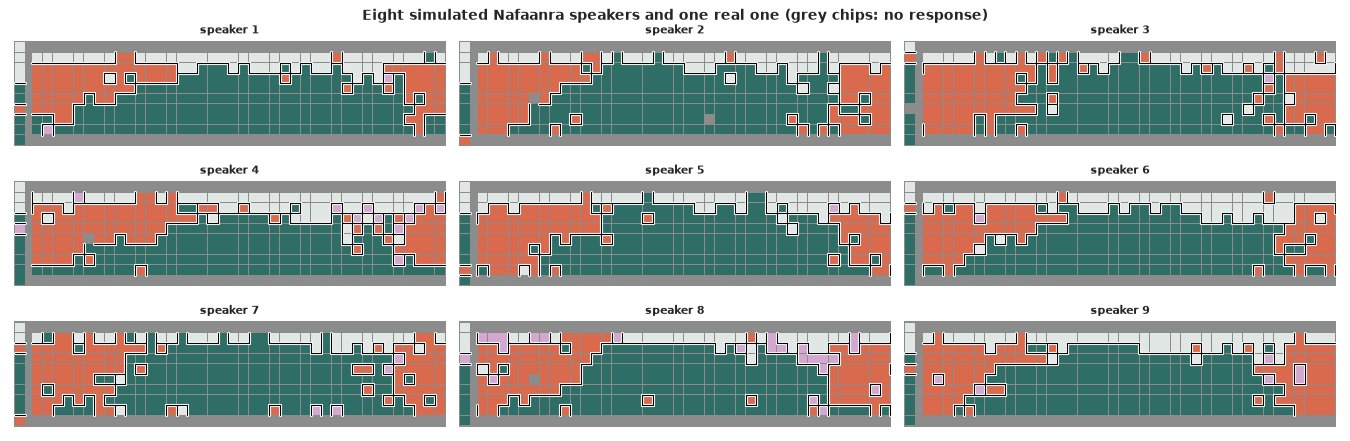

In [15]:
NB = [[] for _ in range(330)]
for (a_, b_) in EDGES:
    NB[a_].append(b_)
    NB[b_].append(a_)


def isolated(y):
    """Chips named, with a non-missing name, differently from every named neighbour."""
    return sum(1 for i in range(330) if y[i] >= 0 and all(y[j] != y[i] for j in NB[i] if y[j] >= 0)
               and any(y[j] >= 0 for j in NB[i]))


g = np.random.default_rng(RANDOM_SEED + 12)
sim = []
for p in new_speaker_probs(idata_hier, n_draws=200, n_new=1, seed=RANDOM_SEED + 13):
    sim.append(np.where(MASK[g.integers(S_N)], sample_names(p[0], g), -1))
iso_sim = np.array([isolated(y) for y in sim])
iso_obs = np.array([isolated(y) for y in NAF["Y"]])
print(f"isolated chips per speaker: real median {np.median(iso_obs):.0f} (range {iso_obs.min()}-{iso_obs.max()}), "
      f"simulated median {np.median(iso_sim):.0f} (90% range {np.quantile(iso_sim, 0.05):.0f}-{np.quantile(iso_sim, 0.95):.0f}); "
      f"share of simulated speakers with at least the real median: {(iso_sim >= np.median(iso_obs)).mean():.2f}")

real_pos = int(g.integers(9))
real_spk = int(g.integers(S_N))
fig, axs = plt.subplots(3, 3, figsize=(15, 4.9), layout="none")
fig.subplots_adjust(left=0.01, right=0.99, top=0.93, bottom=0.01, wspace=0.03, hspace=0.12)
k_sim = 0
for pos, ax in enumerate(axs.flat):
    y = NAF["Y"][real_spk] if pos == real_pos else sim[k_sim]
    k_sim += pos != real_pos
    face = np.where((y >= 0)[:, None], TERM_RGB[np.maximum(y, 0)], 0.55)
    diff = [e for e in range(len(EDGES)) if y[i_e[e]] != y[j_e[e]] and min(y[i_e[e]], y[j_e[e]]) >= 0]
    chip_grid(ax, face=face, edge_w=np.isin(np.arange(len(EDGES)), diff) * 0.9, labels=False)
    ax.set_title(f"speaker {pos + 1}", fontsize=9)
fig.suptitle("Eight simulated Nafaanra speakers and one real one (grey chips: no response)", fontsize=11)
show_jpeg(fig)

Is the real speaker easy to find? The count of isolated chips says: a little. Real speakers have fewer
isolated chips than simulated ones (a median of 12 against 18; 90% of simulated speakers have at least
12), so real naming is somewhat more coherent than "independent given the speaker" - a memory of the
previous chips, or a speaker's categories having more detailed shapes than one shared quadratic plus
linear shifts. In the picture the tell is **B**: in the real speaker it forms coherent patches of pale
pinks and purples, in the simulated speakers it is sprinkled. Both point at the same weakness as the
per-speaker check: a speaker's own category *shapes* are not in the model.

In [16]:
print(f"The real speaker was number {real_pos + 1}.")
#
# ## E. How do languages compare?
#
# Five languages spanning the range of system sizes, fitted with the same hierarchical model (500 draws
# per chain to keep the notebook fast): **Ejagam** (Bantoid, Nigeria; 3 major terms), **Nafaanra** (Gur,
# Ghana; 4), **Bauzi** (Geelvink Bay, Indonesia; 5), **Colorado** (Barbacoan, Ecuador; 6) and **Guaymí**
# (Ngäbere; Chibchan, Panama; 9 major terms plus "other").

The real speaker was number 8.


In [17]:
E_LANGS = [36, 77, 12, 30, 42]
LD = {L: (NAF if L == 77 else lang_data(L)) for L in E_LANGS}
for L in E_LANGS:
    if L == 77:
        continue
    d_ = LD[L]
    idata_L = fit(naming_model(d_["Y"], d_["terms"]), f"{d_['name']} ({d_['T']} terms), hierarchical", draws=500)
    SUM[L] = summarise(idata_L, n_draws=200, seed=RANDOM_SEED + L)
    del idata_L

Ejagam (4 terms), hierarchical       18 s | divergences 0, mean tree depth 5.6, max r_hat(W) 1.032, min ESS(W) 144, max r_hat(sd) 1.009, min ESS(sd) 401


Bauzi (6 terms), hierarchical        29 s | divergences 0, mean tree depth 5.8, max r_hat(W) 1.040, min ESS(W) 209, max r_hat(sd) 1.014, min ESS(sd) 464


Colorado (6 terms), hierarchical     31 s | divergences 0, mean tree depth 6.0, max r_hat(W) 1.009, min ESS(W) 474, max r_hat(sd) 1.007, min ESS(sd) 907


Guaymí (Ngäbere) (10 terms), hierarchical   55 s | divergences 0, mean tree depth 6.0, max r_hat(W) 1.013, min ESS(W) 198, max r_hat(sd) 1.017, min ESS(sd) 413


                  speakers  major terms effective categories, one speaker effective categories, language P(two speakers agree on a chip)
language                                                                                                                                
Ejagam                  25            3                 2.13 [2.07, 2.18]              1.99 [1.91, 2.05]               0.79 [0.77, 0.81]
Nafaanra                29            4                 1.92 [1.87, 1.98]              1.84 [1.77, 1.90]               0.75 [0.71, 0.79]
Bauzi                   25            5                 2.82 [2.69, 2.95]              2.48 [2.35, 2.61]               0.65 [0.62, 0.69]
Colorado                25            6                 3.31 [3.14, 3.47]              2.66 [2.44, 2.84]               0.59 [0.53, 0.65]
Guaymí (Ngäbere)        25            9                 3.07 [2.86, 3.25]              2.25 [2.06, 2.43]               0.39 [0.34, 0.45]


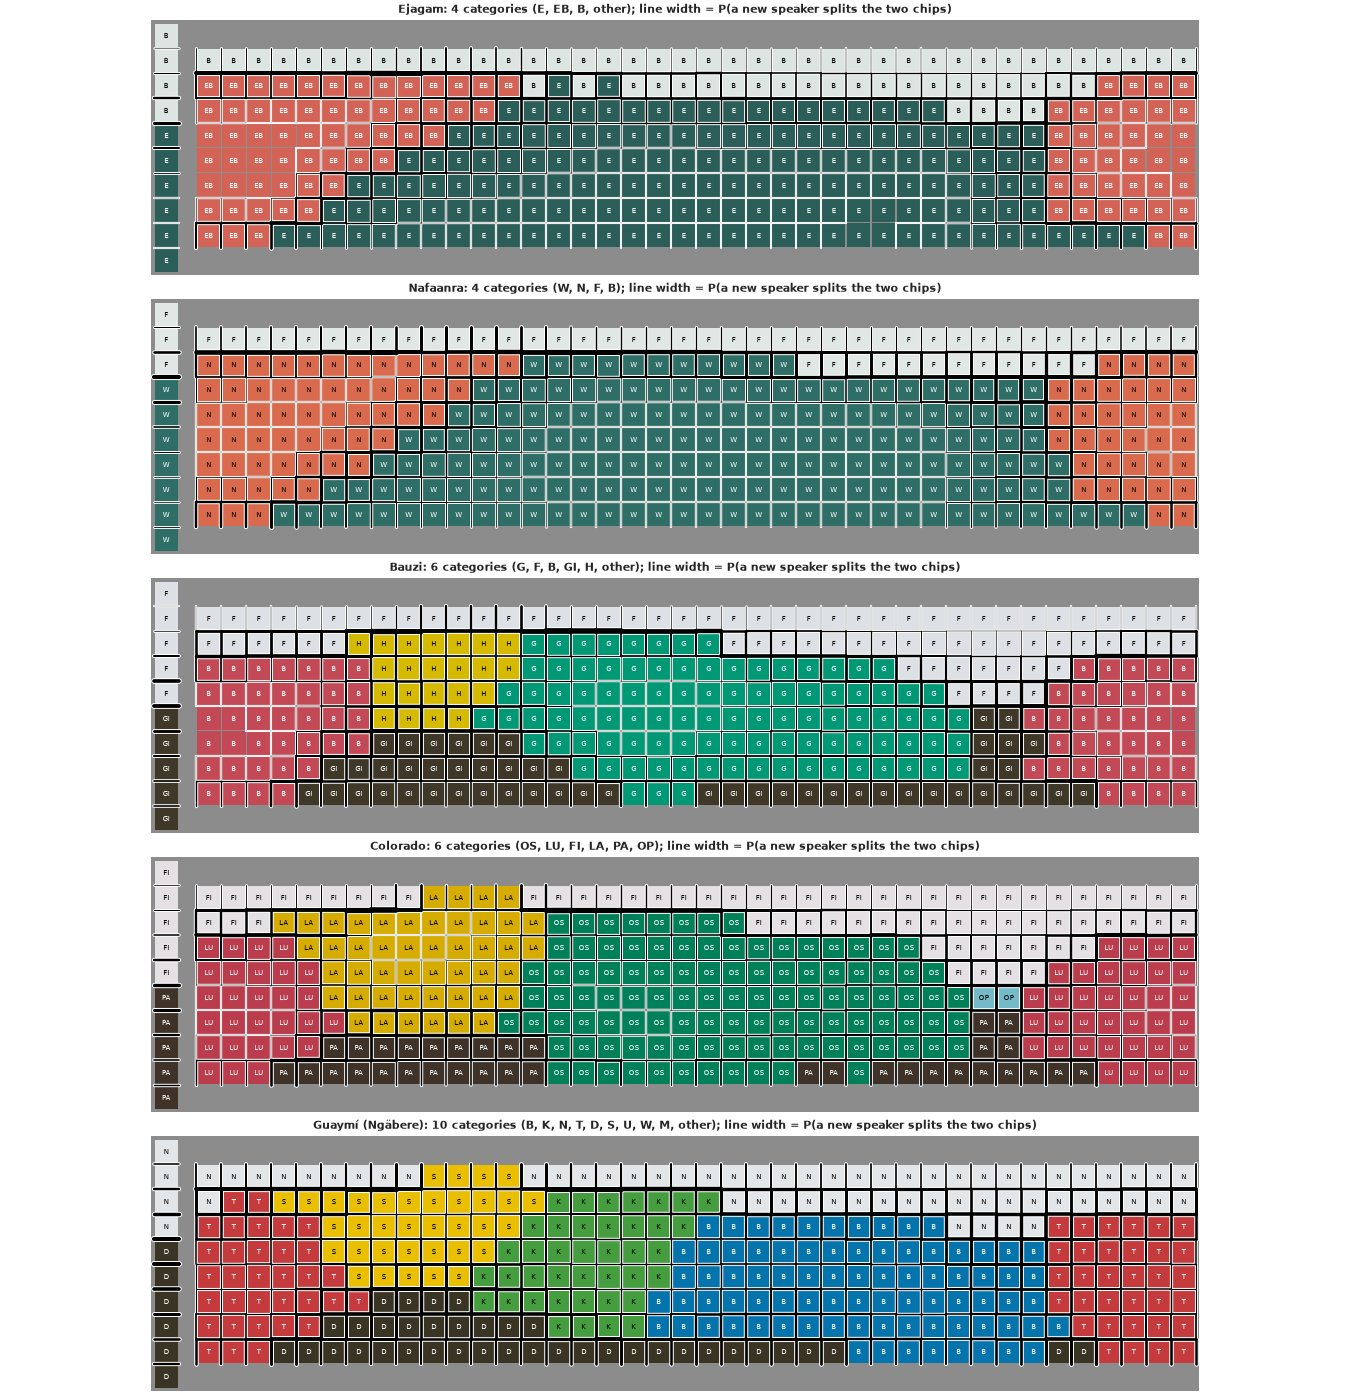

In [18]:
def pop_keff(P):
    """Effective number of categories of the language as a whole (population shares), per draw."""
    return np.exp(entropy(P.mean(1)) - entropy(P).mean(1))


rows_ = []
for L in E_LANGS:
    s_, d_ = SUM[L], LD[L]
    agree = (s_["P"] ** 2).sum(-1).mean(1)
    kp = pop_keff(s_["P"])
    q = lambda x: f"{np.mean(x):.2f} [{np.quantile(x, 0.05):.2f}, {np.quantile(x, 0.95):.2f}]"
    rows_.append({"language": d_["name"], "speakers": d_["S"], "major terms": d_["T"] - ("other" in d_["terms"]),
                  "effective categories, one speaker": q(s_["keff"]), "effective categories, language": q(kp),
                  "P(two speakers agree on a chip)": q(agree)})
print(pd.DataFrame(rows_).set_index("language").to_string())

fig, axs = plt.subplots(len(E_LANGS), 1, figsize=(15, 3.1 * len(E_LANGS)))
for ax, L in zip(axs, E_LANGS):
    Pm = SUM[L]["P"].mean(0)
    posterised(ax, Pm, LD[L]["terms"], edge=5 * SUM[L]["edge"], labels=False,
               title=f"{LD[L]['name']}: {LD[L]['T']} categories ({', '.join(LD[L]['terms'])}); line width = P(a new speaker splits the two chips)")
show_jpeg(fig)

All four fits are clean (no divergences, r_hat at most 1.04 and bulk ESS at least about 140 for the
language weights with 500 draws per chain; Bauzi's and Ejagam's r_hat of 1.03-1.04 are the least
comfortable).

**Effective number of categories.** The number of major terms is a poor measure of how finely a
language divides colour. We measure it by $\exp$ of the mutual information between chip and term: a
language that splits the palette into $k$ equally used, perfectly crisp categories scores $k$. For a
**typical speaker** it goes from about 2 (Ejagam, Nafaanra) to about 3 (Bauzi 2.8, Guaymí 3.1, Colorado
3.3); Guaymí's nine major terms act like three crisp ones, because its categories differ greatly in size
and several are used by some speakers only. For the **language as a whole** (the shares of all its
speakers) the numbers are lower, and the gap is largest for Guaymí (2.25 against 3.07): its speakers
disagree most. Two random Guaymí speakers give the same name to a chip only 39% of the time, against 79%
in Ejagam.

The maps show a common skeleton: a term for white and the palest chips, a dark term, a warm (red) term
that wraps around the ends of the grid. Bauzi adds yellow (H) and splits the dark browns (GI) from
green-blue (G); Colorado adds yellow (LA) and separates green-blue (OS), red (LU) and dark (PA); Guaymí
separates green (K) from blue (B), and yellow (S), red (T) and dark (D). Guaymí's U, W and M are used by
enough speakers to be major terms but are never the most probable term for any chip.

### Do the languages draw their boundaries in the same places?

Two ways to put the five languages on a common footing:

1. **Boundary maps.** Average the new-speaker boundary probabilities of the five languages: an edge
   that is thick in the average is one where most of these languages put a boundary.
2. **Similarity of partitions.** For each pair of languages, the normalised mutual information (NMI)
   between their majority maps (0 = unrelated, 1 = the same partition, up to relabelling), computed per
   posterior draw so it carries an interval. NMI rises with the number of categories, so we also
   compare with the NMI obtained after **rotating one language's map around the hue circle** by a
   random number of columns (lightness structure kept, hue alignment destroyed).

language 1       language 2  NMI  NMI, hue-rotated  P(NMI > rotated median)
    Ejagam         Nafaanra 0.76              0.37                      1.0
    Ejagam            Bauzi 0.56              0.36                      1.0
    Ejagam         Colorado 0.51              0.35                      1.0
    Ejagam Guaymí (Ngäbere) 0.55              0.38                      1.0
  Nafaanra            Bauzi 0.53              0.34                      1.0
  Nafaanra         Colorado 0.49              0.34                      1.0
  Nafaanra Guaymí (Ngäbere) 0.54              0.37                      1.0
     Bauzi         Colorado 0.70              0.41                      1.0
     Bauzi Guaymí (Ngäbere) 0.62              0.43                      1.0
  Colorado Guaymí (Ngäbere) 0.64              0.45                      1.0


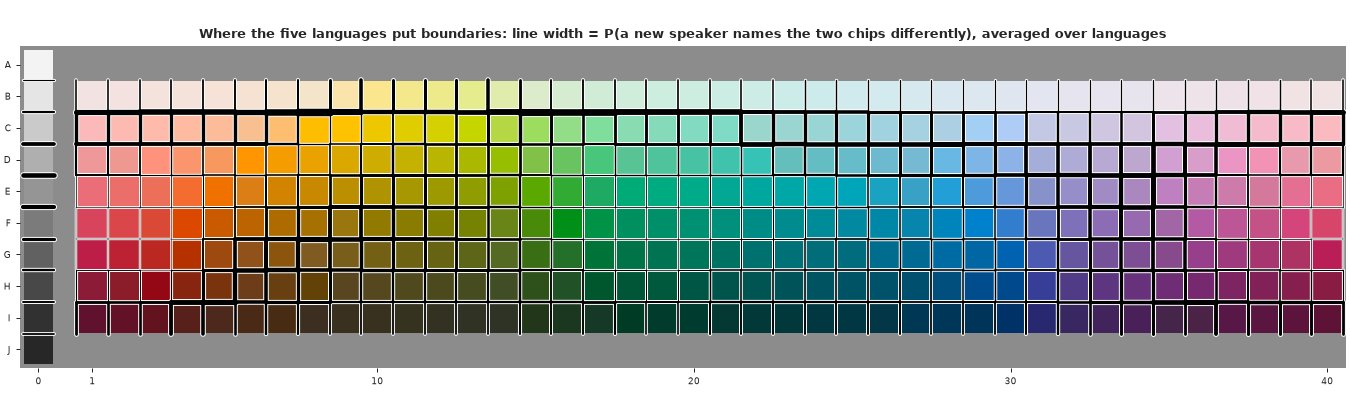

lightness boundaries (mean over the 40 hue columns): {'B|C': 0.52, 'C|D': 0.41, 'D|E': 0.28, 'E|F': 0.22, 'F|G': 0.23, 'G|H': 0.25, 'H|I': 0.32}
strongest hue boundaries (mean over rows B-I): {'34|35': 0.4, '33|34': 0.37, '35|36': 0.35, '32|33': 0.34, '6|7': 0.31, '9|10': 0.31} | median hue edge 0.23


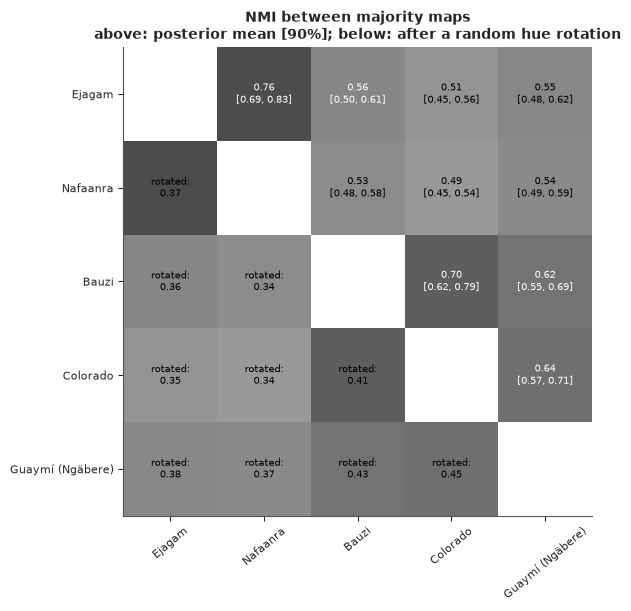

In [19]:
def shifted(k):
    """Index of the chip k hue columns to the left of each chip (greys stay put)."""
    return np.array([i if COL[i] == 0 else CHIP_AT[(ROW[i], (COL[i] - 1 - k) % 40 + 1)] for i in range(330)])


SHIFT = np.array([shifted(k) for k in range(40)])


def nmi(a, b):
    J = np.zeros((a.max() + 1, b.max() + 1))
    np.add.at(J, (a, b), 1)
    J /= J.sum()
    pa, pb = J.sum(1), J.sum(0)
    nz = J > 0
    mi = (J[nz] * np.log(J[nz] / np.outer(pa, pb)[nz])).sum()
    return mi / np.sqrt(entropy(pa) * entropy(pb))


g = np.random.default_rng(RANDOM_SEED + 8)
names_ = [LD[L]["name"] for L in E_LANGS]
M = np.zeros((len(E_LANGS), len(E_LANGS)))
text = np.empty_like(M, dtype=object)
excess = []
for a_, La in enumerate(E_LANGS):
    for b_, Lb in enumerate(E_LANGS):
        if b_ <= a_:
            continue
        ma, mb = SUM[La]["P"].argmax(2), SUM[Lb]["P"].argmax(2)
        n = min(len(ma), len(mb))
        vals = np.array([nmi(ma[d], mb[d]) for d in range(n)])
        rot = np.array([nmi(ma[d][SHIFT[g.integers(1, 40)]], mb[d]) for d in range(n)])
        M[a_, b_] = M[b_, a_] = vals.mean()
        text[a_, b_] = f"{vals.mean():.2f}\n[{np.quantile(vals, 0.05):.2f}, {np.quantile(vals, 0.95):.2f}]"
        text[b_, a_] = f"rotated:\n{rot.mean():.2f}"
        excess.append((names_[a_], names_[b_], vals.mean(), rot.mean(), (vals > np.median(rot)).mean()))
print(pd.DataFrame(excess, columns=["language 1", "language 2", "NMI", "NMI, hue-rotated", "P(NMI > rotated median)"])
      .round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(15, 4.6))
chip_grid(ax, edge_w=7 * np.mean([SUM[L]["edge"] for L in E_LANGS], 0))
ax.set_title("Where the five languages put boundaries: line width = P(a new speaker names the two chips differently), "
             "averaged over languages", fontsize=10)
show_jpeg(fig)
AVG_EDGE = np.mean([SUM[L]["edge"] for L in E_LANGS], 0)
vert = (COL[i_e] == COL[j_e]) & (COL[i_e] > 0)                     # neighbours in lightness (same hue column)
hue = (ROW[i_e] == ROW[j_e])                                       # neighbours in hue (same row)
lb = pd.Series(AVG_EDGE[vert]).groupby([f"{ROWS[r]}|{ROWS[r + 1]}" for r in ROW[i_e][vert]]).mean()
hb = pd.Series(AVG_EDGE[hue]).groupby([f"{c}|{c % 40 + 1}" for c in COL[i_e][hue]]).mean()
print("lightness boundaries (mean over the 40 hue columns):", lb.round(2).to_dict())
print("strongest hue boundaries (mean over rows B-I):", hb.sort_values(ascending=False).head(6).round(2).to_dict(),
      f"| median hue edge {hb.median():.2f}")

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.imshow(np.where(np.eye(len(E_LANGS)) > 0, np.nan, M), cmap="Greys", vmin=0, vmax=1)
for a_ in range(len(E_LANGS)):
    for b_ in range(len(E_LANGS)):
        if a_ != b_:
            ax.text(b_, a_, text[a_, b_], ha="center", va="center", fontsize=7,
                    color="w" if (b_ > a_ and M[a_, b_] > 0.55) else "k")
ax.set_xticks(range(len(E_LANGS)), names_, rotation=40, fontsize=8)
ax.set_yticks(range(len(E_LANGS)), names_, fontsize=8)
ax.set_title("NMI between majority maps\nabove: posterior mean [90%]; below: after a random hue rotation", fontsize=10)
ax.grid(False);

**The five partitions share far more than chance.** Every pair's NMI (0.49-0.76) is above what the same
pair gives after a random hue rotation of one map (0.34-0.45) in every posterior draw. The rotated
values are not zero because rotation keeps the lightness structure (light and dark terms), which all
five share. The most similar pairs are the smallest systems (Ejagam and Nafaanra, 0.76) and the
"middle" ones (Bauzi and Colorado, 0.70).

**Where boundaries fall.** Averaged over the five languages, the strongest line is the one under the
palest row (B|C: a new speaker splits those two chips with probability 0.52), then C|D (0.41) and the
darkest step H|I (0.32); the middle rows are split less often (0.22-0.28). Along the hue circle the
strongest boundaries run through the purples, columns 32-36 (0.34-0.40, where red/warm meets dark/cool
in every language), then at columns 6|7 and 9|10 (0.31; orange to yellow to yellow-green), against a
median hue edge of 0.23. Five languages are few; Part F uses all 110.

## F. Do category centres and best examples cluster across languages?

The classic quantitative claim of this literature (Kay & Regier 2003, *PNAS* 100:9085-9089) is that
the **centroids** of named categories - the average CIELAB colour of the chips a term is used for -
cluster across the world's languages more tightly than chance would allow, where "chance" means the
same languages with their naming rotated by a random number of hue columns. Regier, Kay & Cook (2005,
*PNAS* 102:8386-8391) reported that the **foci** cluster more tightly still. We repeat both tests on
all 110 languages, with two changes:

* **uncertainty from the speakers**: a **Bayesian bootstrap** (Rubin 1981) over each language's
  speakers - Dirichlet(1, ..., 1) weights on speakers, centroids recomputed per draw - which respects
  the lesson of Part C that responses cluster by speaker. (Fitting the hierarchical model to all 110
  languages would take over an hour here; the bootstrap is its nonparametric stand-in for this
  question.)
* a fixed set of terms: the **major** terms of each language that have at least one focus.

The statistic is a **dispersion** in the spirit of Kay & Regier's (our reading of their measure): for
every ordered pair of languages, the sum over the first language's centroids of the CIELAB distance
to the nearest centroid of the second.

In [20]:
ALL = sorted(langs.index)
cat_lang, n_st, lab_st, fn_st, flab_st, N_ct, F_ct = [], [], [], [], [], [], []
for L in ALL:
    d_ = lang_data(L)
    T_ = d_["T"] - ("other" in d_["terms"])
    fs, ft, fchip = d_["foci"]
    ok_t = [t for t in range(T_) if (ft == t).any()]
    Y = d_["Y"]
    oh = np.stack([(Y == t) for t in ok_t], -1).astype(float)          # S x C x T'
    n_st.append(oh.sum(1))
    lab_st.append(np.einsum("sct,cj->stj", oh, LAB))
    fo = np.zeros((d_["S"], 330, len(ok_t)))
    for k_, t in enumerate(ok_t):
        m_ = (ft == t) & (fs >= 0)
        np.add.at(fo, (fs[m_], fchip[m_], k_), 1)
    fn_st.append(fo.sum(1))
    flab_st.append(np.einsum("sct,cj->stj", fo, LAB))
    N_ct.append(oh.sum(0))
    F_ct.append(fo.sum(0))
    cat_lang += [L] * len(ok_t)
cat_lang = np.array(cat_lang)
STARTS = np.r_[0, np.flatnonzero(np.diff(cat_lang)) + 1]
LANG_POS = np.searchsorted(ALL, cat_lang)
print(f"{len(cat_lang)} categories (major terms with foci) in {len(ALL)} languages; "
      f"{sum(len(n) for n in n_st)} speakers")


def dispersion(C):
    Dm = np.sqrt(((C[:, None] - C[None]) ** 2).sum(-1))
    Mn = np.minimum.reduceat(Dm, STARTS, axis=1)
    Mn[np.arange(len(C)), LANG_POS] = 0
    return Mn.sum()


def boot_centroids(ns, labs, g):
    out = []
    for n_, l_ in zip(ns, labs):
        w = g.dirichlet(np.ones(len(n_)))
        out.append((w @ l_.reshape(len(w), -1)).reshape(-1, 3) / np.maximum(w @ n_, 1e-12)[:, None])
    return np.concatenate(out)


def rotated_centroids(counts_ct, g):
    out = []
    for N in counts_ct:
        k = g.integers(40)
        out.append((N.T @ LAB[SHIFT[k]]) / np.maximum(N.sum(0), 1e-12)[:, None])
    return np.concatenate(out)


g = np.random.default_rng(RANDOM_SEED + 9)
t0 = time.time()
res = {}
for label, ns, labs, cts in (("naming centroids", n_st, lab_st, N_ct), ("foci", fn_st, flab_st, F_ct)):
    obs = np.array([dispersion(boot_centroids(ns, labs, g)) for _ in range(300)])
    null = np.array([dispersion(rotated_centroids(cts, g)) for _ in range(1000)])
    res[label] = (obs, null)
print(f"{time.time() - t0:.0f} s for 2 x (300 bootstrap + 1000 rotation) dispersions")
rows_ = []
for label, (obs, null) in res.items():
    r = obs / null.mean()
    rows_.append({"": label, "observed dispersion": f"{obs.mean():,.0f} [{np.quantile(obs, 0.05):,.0f}, {np.quantile(obs, 0.95):,.0f}]",
                  "rotation null (mean, 5%-95%)": f"{null.mean():,.0f} ({np.quantile(null, 0.05):,.0f}-{np.quantile(null, 0.95):,.0f})",
                  "observed / null mean": f"{r.mean():.3f} [{np.quantile(r, 0.05):.3f}, {np.quantile(r, 0.95):.3f}]",
                  "share of rotations at or below the observed": f"{(null[None] <= obs[:, None]).mean():.4f}"})
print(pd.DataFrame(rows_).set_index("").to_string())
rn = res["naming centroids"][0] / res["naming centroids"][1].mean()
rf = res["foci"][0] / res["foci"][1].mean()
print(f"\nfoci minus naming, in units of their own null mean: {np.mean(rf - rn):+.3f} "
      f"[{np.quantile(rf - rn, 0.05):+.3f}, {np.quantile(rf - rn, 0.95):+.3f}] (bootstrap draws paired by index)")

872 categories (major terms with foci) in 110 languages; 2616 speakers


32 s for 2 x (300 bootstrap + 1000 rotation) dispersions
                               observed dispersion     rotation null (mean, 5%-95%)  observed / null mean share of rotations at or below the observed
                                                                                                                                                     
naming centroids  1,408,131 [1,398,513, 1,416,778]  1,774,755 (1,763,303-1,784,438)  0.793 [0.788, 0.798]                                      0.0000
foci              1,780,876 [1,761,361, 1,799,413]  2,023,071 (1,993,231-2,050,617)  0.880 [0.871, 0.889]                                      0.0000

foci minus naming, in units of their own null mean: +0.087 [+0.075, +0.097] (bootstrap draws paired by index)


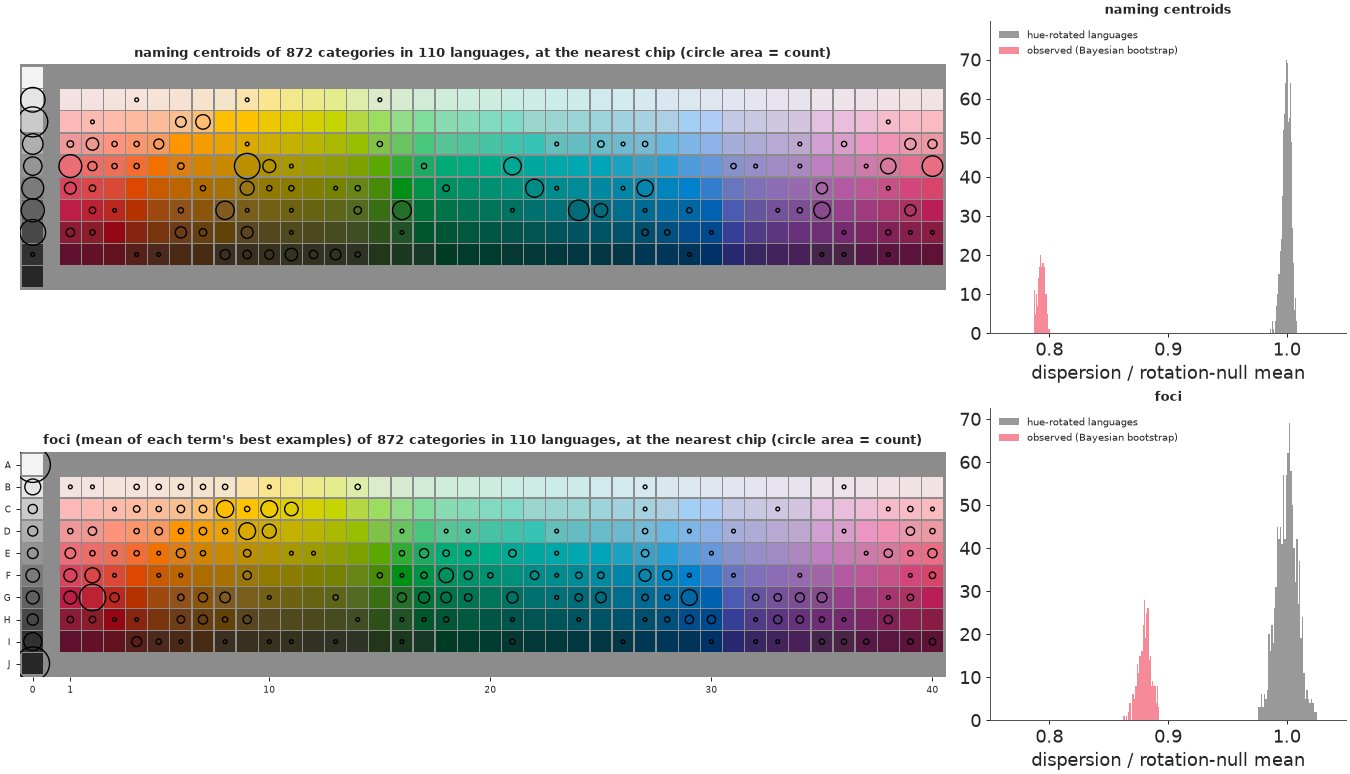

In [21]:
Cn = np.concatenate([(l_.sum(0)) / n_.sum(0)[:, None] for n_, l_ in zip(n_st, lab_st)])
Cf = np.concatenate([(l_.sum(0)) / n_.sum(0)[:, None] for n_, l_ in zip(fn_st, flab_st)])
fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 2, width_ratios=[2.6, 1])
for r_, (label, C) in enumerate((("naming centroids", Cn), ("foci (mean of each term's best examples)", Cf))):
    ax = fig.add_subplot(gs[r_, 0])
    near = np.argmin(((C[:, None] - LAB[None]) ** 2).sum(-1), 1)
    cnt_ = np.bincount(near, minlength=330)
    chip_grid(ax, labels=r_ == 1)
    k = cnt_ > 0
    ax.scatter(XPOS[k], YPOS[k], s=9 * cnt_[k], facecolor="none", edgecolor="k", lw=1.1, zorder=5)
    ax.set_title(f"{label} of {len(C)} categories in 110 languages, at the nearest chip (circle area = count)", fontsize=10)
    ax = fig.add_subplot(gs[r_, 1])
    obs, null = res["naming centroids" if r_ == 0 else "foci"]
    ax.hist(null / null.mean(), bins=40, color="0.6", label="hue-rotated languages")
    ax.hist(obs / null.mean(), bins=30, color="C1", alpha=0.8, label="observed (Bayesian bootstrap)")
    ax.set_xlim(0.75, 1.05)
    ax.set_xlabel("dispersion / rotation-null mean")
    ax.set_title(label.split(" (")[0], fontsize=10)
    ax.legend(fontsize=8)
show_jpeg(fig)

**Naming centroids cluster, strongly.** Across 872 categories in 110 languages, the observed dispersion
is 0.79 [0.788, 0.798] of what hue-rotated languages give, and not one of 1,000 rotations comes as low.
The Bayesian bootstrap over speakers says this is not a matter of which speakers were interviewed: the
whole posterior is far from the null. This reproduces Kay & Regier's finding (who rotated each
language's modal naming map; we rotate all responses).

**Foci cluster too** (0.88 [0.871, 0.889] of their null, again below every rotation), but under this
statistic they cluster *less* tightly than the naming centroids, not more: relative to its own null,
the foci ratio is higher by 0.087 [0.075, 0.097]. In absolute terms foci are also more spread out, which
is expected: centroids are averages of many chips and are pulled towards the grey axis (see the map:
centroids pile up at the greys and mid-lightness chips), while foci sit at saturated chips and at pure
white and black. So on this statistic we do **not** reproduce the ordering that Regier, Kay & Cook
reported. Their analysis differed from ours in its details (which terms, how foci are summarised, the
measure of clustering), which we have not replicated, so read this as "not robust to the choice of
statistic", not as a refutation. The maps make the qualitative picture clear either way: foci
concentrate on a few places - white, black, the reds of columns 1-3 in rows F-G, the yellows around
C8-C11, greens around F-G 16-18 and blues around G29 - that are the same in language after language.

## G. Predicting a new speaker, and choosing what to ask

Back to Nafaanra and the split of Part B: 20 training speakers and 9 held-out speakers. The hierarchical
model is refitted to the training speakers. For each held-out speaker we set aside 150 random chips
for scoring, and let ourselves **ask** about up to 40 of the other chips. After each answer the
speaker's effects are updated and the 150 scoring chips predicted. The scoring set is drawn 3 times
per speaker and the results averaged (a first version with a single draw was too noisy to compare
the two question strategies). We report the score on all scoring chips and on the **contested** ones,
where a new speaker's most probable term has probability below 0.8 - the chips where knowing the
speaker can matter.

The update needs the posterior of one new speaker's effects given the answers so far, with the
language-level parameters uncertain. We do it by **importance sampling**: 8,000 particles, each a
posterior draw of the language plus a fresh draw of speaker effects, weighted by the likelihood of
the answers (16 speaker parameters and at most 40 answers; we report the effective sample size).
Two ways to choose the next chip:

* **random**;
* **most informative**: the chip whose answer has the highest **expected information gain** about the
  speaker's naming, the mutual information between the answer and the particle,
  $\;\mathrm{EIG}(c) = H\big[\sum_i w_i\, p_i(\cdot\mid c)\big] - \sum_i w_i\, H\big[p_i(\cdot\mid c)\big]$,
  recomputed after every answer (an adaptive design).

The pooled model cannot learn from answers: its prediction for every speaker is the population.

In [22]:
idata_tr = fit(naming_model(Ytr, NAF["terms"]), "Nafaanra, hierarchical, 20 training speakers")
PART = np.concatenate([p for p in new_speaker_probs(idata_tr, n_draws=500, n_new=16, seed=RANDOM_SEED + 10)])
LOG_PART = np.log(np.clip(PART, 1e-300, 1))
H_PART = entropy(PART)                                            # particles x chips
POP_TR = PART.mean(0)                                             # new-speaker predictive, no answers
CONTESTED = POP_TR.max(1) < 0.8                                   # chips where speakers often disagree
# a reference: how much better are TRAINING speakers predicted by their own fitted effects (in-sample)?
Wd, sdd, zd = draws_of(idata_tr, "W", 200), draws_of(idata_tr, "sd", 200), draws_of(idata_tr, "z", 200)
Ws = np.repeat(Wd[:, None], len(TRAIN), 1)
Ws[:, :, :4] += sdd[:, None] * zd
P_own = softmax(np.einsum("ck,dskt->dsct", F_LAB, Ws)).mean(0)
s_, c_ = np.nonzero(Ytr >= 0)
own_gain = np.log(P_own[s_, c_, Ytr[s_, c_]]) - np.log(POP_TR[c_, Ytr[s_, c_]])
print(f"contested chips (new-speaker probability of the top term < 0.8): {CONTESTED.sum()} of 330")
print(f"in-sample reference, training speakers scored with their own effects instead of the population's: "
      f"+{own_gain.mean():.3f} nats per chip, +{own_gain[CONTESTED[c_]].mean():.3f} on contested chips")
del idata_tr, Ws

P_pooled_tr = pooled_P["CIELAB quadratic"].mean(0)
KS = [0, 2, 5, 10, 20, 40]
N_SPLIT = 3
g = np.random.default_rng(RANDOM_SEED + 11)
res = {st: np.zeros((len(TEST) * N_SPLIT, len(KS), 2)) for st in ("random", "most informative")}
pooled_sc = np.zeros((len(TEST) * N_SPLIT, 2))
ess_end, asked = {st: [] for st in res}, np.zeros(330)
calib = {"pooled": [], "hierarchical, 0 answers": [], "hierarchical, 20 answers (most informative)": []}


def score(pred, y, ev):
    lp = np.log(pred[np.arange(len(ev)), y[ev]])
    return lp.mean(), lp[CONTESTED[ev]].mean()


row = 0
for s in TEST:
    y = NAF["Y"][s]
    have = np.flatnonzero(y >= 0)
    for split in range(N_SPLIT):
        ev = g.choice(have, 150, replace=False)                   # scoring chips
        pool0 = np.setdiff1d(have, ev)                            # chips we may ask about
        pooled_sc[row] = score(P_pooled_tr[ev], y, ev)
        if split == 0:
            calib["pooled"].append((P_pooled_tr[ev], y[ev]))
        for strat in res:
            logw, pool = np.zeros(len(PART)), list(pool0)
            for n_asked in range(max(KS) + 1):
                w = np.exp(logw - logw.max())
                w /= w.sum()
                if n_asked in KS:
                    pred = np.einsum("i,ict->ct", w, PART[:, ev])
                    res[strat][row, KS.index(n_asked)] = score(pred, y, ev)
                    if split == 0 and n_asked == 0 and strat == "random":
                        calib["hierarchical, 0 answers"].append((pred, y[ev]))
                    if split == 0 and n_asked == 20 and strat == "most informative":
                        calib["hierarchical, 20 answers (most informative)"].append((pred, y[ev]))
                if n_asked == max(KS):
                    ess_end[strat].append(1 / (w**2).sum())
                    break
                if strat == "random":
                    c = pool.pop(g.integers(len(pool)))
                else:
                    pbar = np.einsum("i,ict->ct", w, PART[:, pool])
                    c = pool.pop(int(np.argmax(entropy(pbar) - w @ H_PART[:, pool])))
                    if n_asked < 10 and split == 0:
                        asked[c] += 1
                logw += LOG_PART[:, c, y[c]]
        row += 1
print(f"importance-sampling ESS after {max(KS)} answers (of {len(PART):,} particles): "
      + ", ".join(f"{k} median {np.median(v):.0f}, min {np.min(v):.0f}" for k, v in ess_end.items()))
gain = {k: (v - v[:, :1]).reshape(len(TEST), N_SPLIT, len(KS), 2).mean(1) for k, v in res.items()}  # per speaker
pooled_sc = pooled_sc.reshape(len(TEST), N_SPLIT, 2).mean(1)
res = {k: v.reshape(len(TEST), N_SPLIT, len(KS), 2).mean(1) for k, v in res.items()}
tab = pd.DataFrame({(f"{k}", sub): [f"{gain[k][:, j, i].mean():+.3f} ± {gain[k][:, j, i].std(ddof=1) / np.sqrt(len(TEST)):.3f}"
                                    for j in range(len(KS))] for k in res for i, sub in enumerate(["all chips", "contested"])},
                   index=pd.Index(KS, name="answers"))
print(f"\ngain in log score per scoring chip over the no-answer prediction (per speaker: mean over {N_SPLIT} random "
      f"scoring sets; mean ± se over the {len(TEST)} speakers):")
print(tab.to_string())
d_ = gain["most informative"] - gain["random"]
print("\nmost informative minus random:", {k: f"{d_[:, j, 1].mean():+.3f} ± {d_[:, j, 1].std(ddof=1) / np.sqrt(len(TEST)):.3f}"
                                           for j, k in enumerate(KS) if k > 0}, "(contested chips)")
print(f"with no answers: hierarchical {res['random'][:, 0, 0].mean():.3f}, pooled {pooled_sc[:, 0].mean():.3f} "
      f"(all chips); contested: {res['random'][:, 0, 1].mean():.3f} vs {pooled_sc[:, 1].mean():.3f}")

Nafaanra, hierarchical, 20 training speakers   14 s | divergences 0, mean tree depth 5.0, max r_hat(W) 1.018, min ESS(W) 398, max r_hat(sd) 1.007, min ESS(sd) 719


contested chips (new-speaker probability of the top term < 0.8): 116 of 330
in-sample reference, training speakers scored with their own effects instead of the population's: +0.068 nats per chip, +0.112 on contested chips


importance-sampling ESS after 40 answers (of 8,000 particles): random median 578, min 8, most informative median 161, min 44

gain in log score per scoring chip over the no-answer prediction (per speaker: mean over 3 random scoring sets; mean ± se over the 9 speakers):
                 random                 most informative                
              all chips       contested        all chips       contested
answers                                                                 
0        +0.000 ± 0.000  +0.000 ± 0.000   +0.000 ± 0.000  +0.000 ± 0.000
2        +0.006 ± 0.002  +0.015 ± 0.005   +0.007 ± 0.004  +0.017 ± 0.007
5        +0.009 ± 0.001  +0.020 ± 0.008   +0.015 ± 0.005  +0.031 ± 0.011
10       +0.012 ± 0.004  +0.026 ± 0.011   +0.018 ± 0.007  +0.041 ± 0.018
20       +0.014 ± 0.004  +0.029 ± 0.013   +0.021 ± 0.006  +0.053 ± 0.016
40       +0.017 ± 0.005  +0.032 ± 0.014   +0.027 ± 0.007  +0.069 ± 0.013

most informative minus random: {2: '+0.002 ± 0.010', 5: '+0.011 ± 0.012'

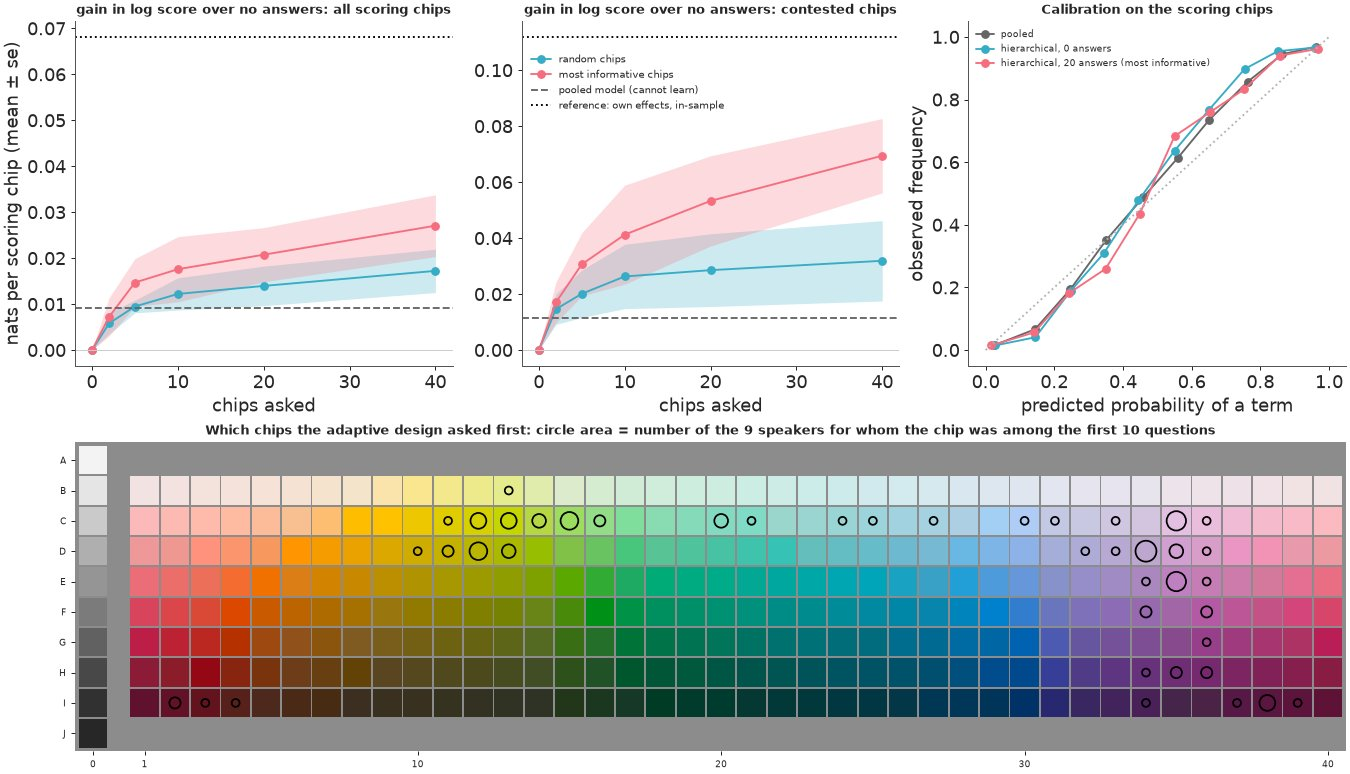

In [23]:
fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.95])
for i, sub in enumerate(["all scoring chips", "contested chips"]):
    ax = fig.add_subplot(gs[0, i])
    for k, col in (("random", "C0"), ("most informative", "C1")):
        m_ = gain[k][:, :, i].mean(0)
        se_ = gain[k][:, :, i].std(0, ddof=1) / np.sqrt(len(TEST))
        ax.fill_between(KS, m_ - se_, m_ + se_, color=col, alpha=0.25, lw=0)
        ax.plot(KS, m_, "o-", color=col, label=f"{k} chips")
    ax.axhline(pooled_sc[:, i].mean() - res["random"][:, 0, i].mean(), color="0.4", ls="--", label="pooled model (cannot learn)")
    ref = own_gain.mean() if i == 0 else own_gain[CONTESTED[c_]].mean()
    ax.axhline(ref, color="k", ls=":", label="reference: own effects, in-sample")
    ax.axhline(0, color="0.8", lw=0.8)
    ax.set_xlabel("chips asked")
    ax.set_title(f"gain in log score over no answers: {sub}", fontsize=10)
axs0 = fig.axes
axs0[0].set_ylabel("nats per scoring chip (mean ± se)")
axs0[1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, 0.93))
ax = fig.add_subplot(gs[0, 2])
bins = np.linspace(0, 1, 11)
for (k, v), col in zip(calib.items(), ["0.4", "C0", "C1"]):
    pr = np.concatenate([p_ for p_, _ in v]).ravel()
    ob = np.concatenate([(yy[:, None] == np.arange(T_N)[None]) for _, yy in v]).ravel()
    b = np.clip(np.digitize(pr, bins) - 1, 0, 9)
    ok = [i for i in range(10) if (b == i).sum() > 20]
    ax.plot([pr[b == i].mean() for i in ok], [ob[b == i].mean() for i in ok], "o-", color=col, label=k)
ax.plot([0, 1], [0, 1], color="0.7", ls=":")
ax.set_xlabel("predicted probability of a term")
ax.set_ylabel("observed frequency")
ax.set_title("Calibration on the scoring chips", fontsize=10)
ax.legend(fontsize=7)
ax = fig.add_subplot(gs[1, :])
chip_grid(ax)
k = asked > 0
ax.scatter(XPOS[k], YPOS[k], s=40 * asked[k], facecolor="none", edgecolor="k", lw=1.4, zorder=5)
ax.set_title("Which chips the adaptive design asked first: circle area = number of the 9 speakers for whom the chip was "
             "among the first 10 questions", fontsize=10)
show_jpeg(fig)

Reading the results (gains in log score per scoring chip, relative to the same model with no answers):

* **Knowing a speaker is worth something, but not much.** Even in-sample, predicting training speakers
  with their own fitted effects instead of the population's gains only 0.068 nats per chip (0.11 on the
  116 contested chips); most chips are named the same way by everyone.
* **Asking helps, and asking well helps more.** After 40 answers, random chips gain 0.017 ± 0.005 nats
  per scoring chip (0.032 on contested chips); chips chosen by expected information gain gain 0.027 ±
  0.007 (0.069 ± 0.013 on contested chips, most of the in-sample reference). On contested chips the
  adaptive design beats random by 0.038 ± 0.006 after 40 answers; after 2-10 answers the difference is
  within noise.
* **With no answers, the pooled model is slightly better** than the hierarchical one (-0.389 vs -0.398
  per chip): the hierarchical population average is a mixture of speaker-level softmaxes with a shared
  shape, and pays a little for that restriction on the per-chip margins. The hierarchical model's value
  is elsewhere: honest per-speaker variation (Part C) and the ability to learn a speaker at all.
* **Calibration** is good for all three predictions (the points follow the diagonal, with mild
  under-confidence around 0.7-0.8).
* The adaptive design asks about the chips where speakers disagree and that decide the most: the
  yellow-greens of rows C-D (the F/N/W junction), pale cyans and blues of row C (the F/W boundary), the
  pale purples and pinks of columns 33-36 (the B region and the purple/red boundary), and a few dark
  reds. None of its first ten questions is about a core chip.

The importance weights held up: after 40 answers the effective sample size has a median of 161-578 of
8,000 particles, with a worst case of 8 for one speaker under random questions (that speaker's last
predictions are noisier).

## Summary

* **A colour naming model is a multinomial regression in colour space.** Gaussian categories written
  as softmax over quadratic CIELAB logits, with zero-sum weights, sample in seconds; the "centre and
  width" form of the same model is a ridge. CIELAB knows that hue is a circle; a model on the printed
  grid must be told (hue as a line cost 100 nats on 9 held-out speakers).
* **Check at the level of the real unit.** Pooling all speakers reproduces every chip's shares and still
  fails a per-speaker check completely (0 of 200 replicated sets as varied as the real speakers). A
  hierarchical model with speaker-level intercepts and linear shifts passes it; a lineup and an
  isolated-chip count show what it still misses (speakers' own category shapes, B as a sometimes-term).
* **Two uncertainties, two displays.** New speakers vary a lot along boundaries (71 Nafaanra chips
  with P(top term) < 0.7); the language itself is pinned down to about a chip (only 26 chips with an
  uncertain majority). With the chips drawn in their own colours, glyphs, their size and opacity,
  boundary lines whose width is a probability, disc-and-ring charts for intervals, a posterised
  animation of new speakers and a lineup carry the uncertainty.
* **A focus is not the safest exemplar.** Speakers' best examples are extremes (black for the dark term,
  crimson for the red term); the chips most reliably named are elsewhere.
* **Across languages**: effective categories grow much more slowly than the number of terms (a 9-term
  system acts like 3 crisp categories per speaker), partitions share far more structure than
  hue-rotated versions (NMI 0.49-0.76 against 0.34-0.45), and naming centroids of all 110 languages
  cluster strongly (0.79 of the rotation null). Foci cluster too, but on our statistic less than
  centroids - a published ordering that did not survive a change of statistic.
* **Prediction and design**: a few answers teach us about a new speaker, adaptive questions (expected
  information gain) roughly double the gain on the chips that matter, and all the predictions are
  calibrated.

## Try it yourself

1. **Efficient communication.** Regier, Kay & Khetarpal argued that colour naming systems are near-optimal
   partitions of perceptual colour space, and later work (Zaslavsky, Kemp, Regier & Tishby) framed this as
   an information-bottleneck trade-off between the complexity of a naming system and how accurately a
   listener can reconstruct the speaker's colour. Using the population shares of Part E as each language's
   encoder (and a Gaussian perceptual noise model in CIELAB for the listener), compute complexity and
   accuracy per posterior draw for the five languages, with intervals. Which are closest to the
   trade-off frontier traced by hue-rotated or randomly perturbed partitions?
2. **Who are the speakers?** `wcs_naming` records each speaker's age and sex (where known). Put them in
   the speaker-level model - a regression for the speaker effects $z$ - and ask whether, in Nafaanra,
   the B term is a matter of age. How would you check that the answer is not an artefact of which
   fieldworker interviewed whom?
3. **One model for many languages.** Replace the Bayesian bootstrap of Part F by a model: each language's
   categories drawn from a shared, finite set of "universal" prototypes in CIELAB (a mixture, with
   language-specific weights and shifts). Fit it to a dozen languages and read off the posterior
   spread of the prototypes. Does the hue-rotation test of Part F become a statement about a parameter?